In [1]:
import sys
import pickle
import copy
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import networkx as nx
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import seaborn as sns
import matplotlib.lines as mlines
from sklearn.cluster import KMeans


import cartopy.crs as ccrs
import cartopy


from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

root_path = '../' # This defaults to './', which should be the repository pathimport os
os.chdir(root_path)
sys.path.append(root_path)
from utils.config import path_to_pypsa_network_sclopf, path_to_cascade_results, path_to_vis_results, path_to_pre_outage, path_to_evaluation_results, path_to_figures
from utils import data_handling, cascade_simulation

n_nodes = 400

save_path = path_to_figures
os.makedirs(save_path, exist_ok=True)

# Setup

In [2]:
# Load network graph and node positions
# (it is equal for all CO2 levels)
snet_index = 0
network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        "sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc", True)
nx_graph = data_handling.build_networkx_graph(network, snet_index= snet_index)
pos = nx.get_node_attributes(nx_graph, 'pos')
I_m, B_d, num_parallels, line_limits = data_handling.get_matrices_from_nx_graph(nx_graph)
n_lines = nx_graph.number_of_edges()

# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
bridge_idxs = data_handling.nx_edges_to_matrix_indices(nx.bridges(nx_graph),
                                                           nx_graph)
n_2_failures = cascade_simulation.calc_possible_double_line_failures(num_parallels,
                                                                     ignored_idxs=bridge_idxs)
num_failures = len(n_2_failures)
num_failures_weighted = network.snapshot_weightings.objective.sum() * num_failures
n_snapshots = network.snapshots.shape[0]

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [3]:
co2ls = np.arange(0.0,0.61,0.1).round(1)
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])
selected_co2ls = np.array([0.0, 0.2, 0.6])

# Figure 2: generation map

In [4]:
# drop the 0.7 and 0.8 columns because they carry no relevant information, see old plots
generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}-2920SEG.nc", True)
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.3-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.4-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/mtitz/.conda/envs/system_split/lib/python3.12/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


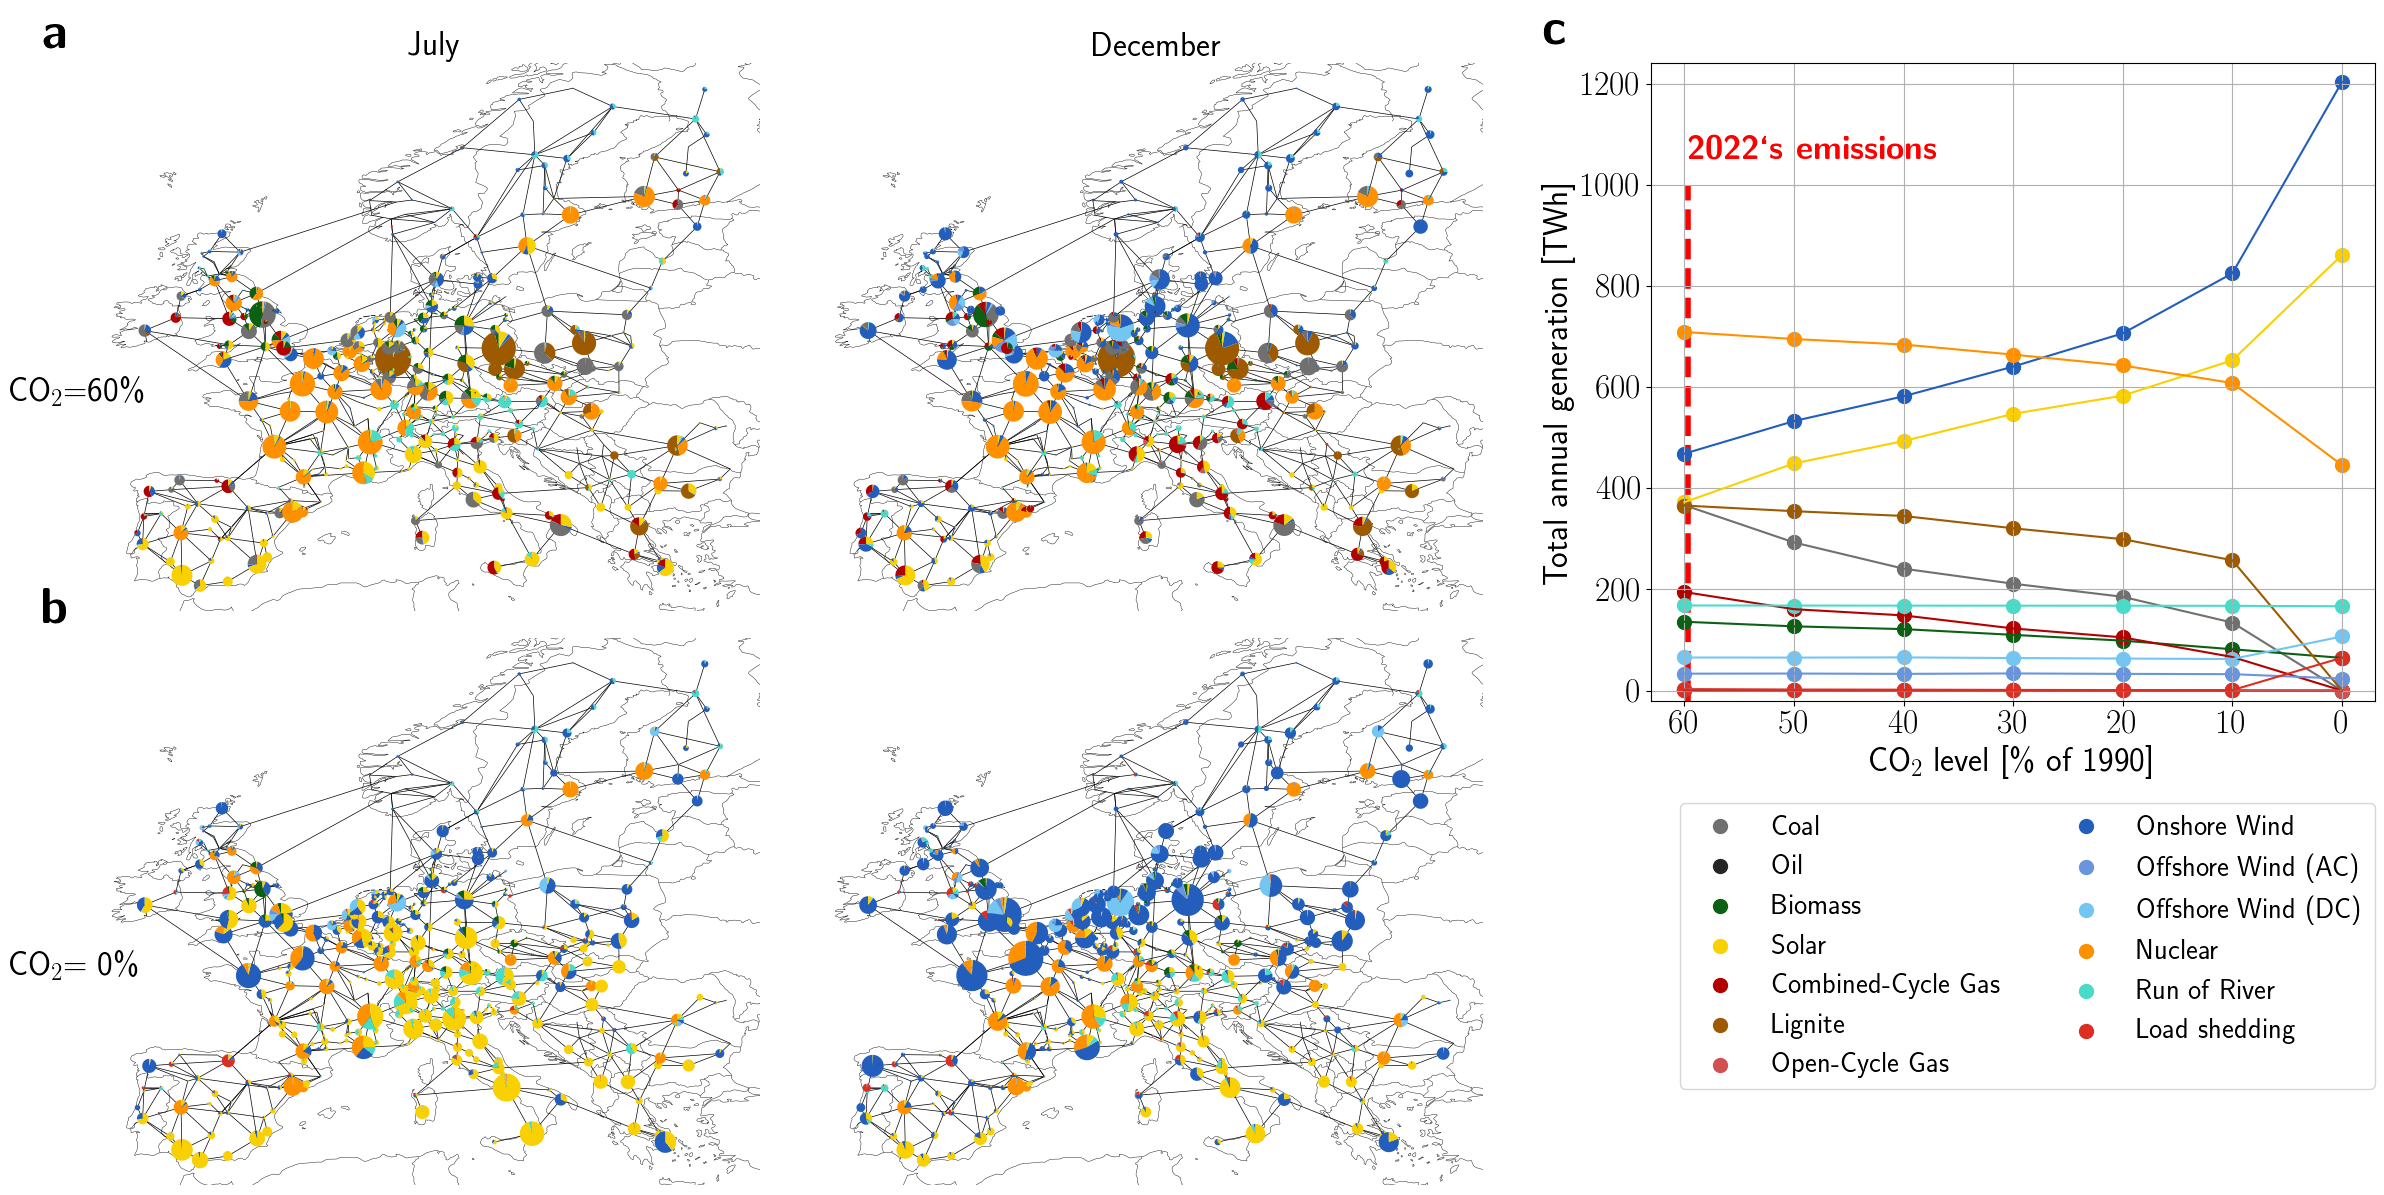

In [5]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.0]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_primary = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
    n = network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
#     n = data_handling.load_pypsa_network(target_level, n_nodes, path_to_pypsa_network_sclopf)
    for j, month in enumerate(months):

       axs_primary[i][j].set_ylim([0, vmax])
       current_snapshots = n.snapshots[n.snapshots.month == month]
       current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
       current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
       n.plot(bus_sizes=current_gen/7e6,
              line_colors='black',
              link_colors='black',
              link_widths=0.5,
              line_widths=0.5,
              ax=axs_primary[i][j])

       if i == 0:
              axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

       axs_primary[i][j].text(0 - 0.1, 1+0.05,
                     labels[i][j],
                     fontsize=36,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_primary[i][j].transAxes)


axs_primary[0][0].text(0 - 0.15, 0.4,
               r'CO$_2$=60\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[0][0].transAxes)
axs_primary[1][0].text(0 - 0.15, 0.4,
               r'CO$_2$= 0\%',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[1][0].transAxes)

###### panel c ######

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
for ind,data in generation_by_carrier_and_co2l.iterrows():
    ax3.scatter(co2s[index]*100,
                (data.values)[index]*1e-6,
                color=n.carriers.set_index('nice_name').color.loc[ind],
                label=ind,
                s=100)

    ax3.plot(co2s[index]*100,
             (data.values)[index]*1e-6,
             color=n.carriers.set_index('nice_name').color.loc[ind])


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12.4e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(save_path+'generation_mix_versus_co2level.pdf', bbox_inches='tight')

# Storage map plots

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


...

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc


/home/mtitz/.conda/envs/system_split/lib/python3.12/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


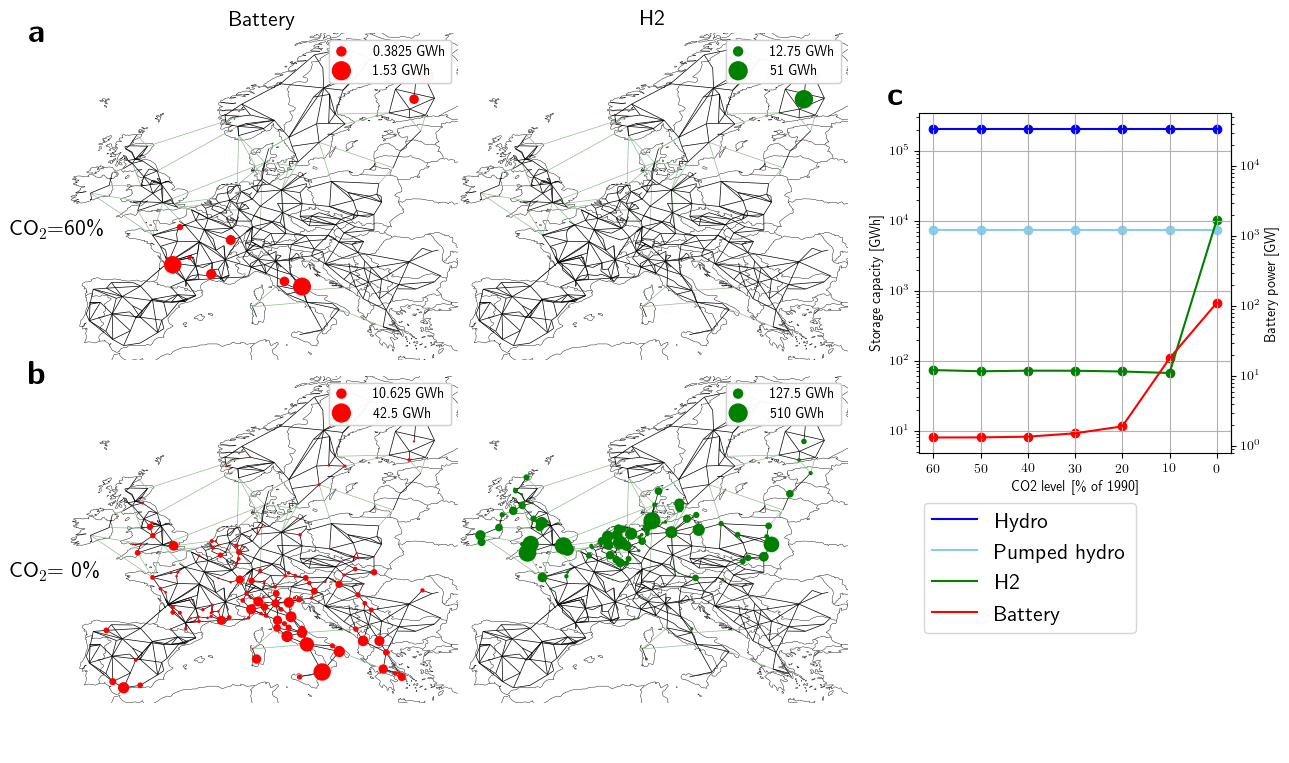

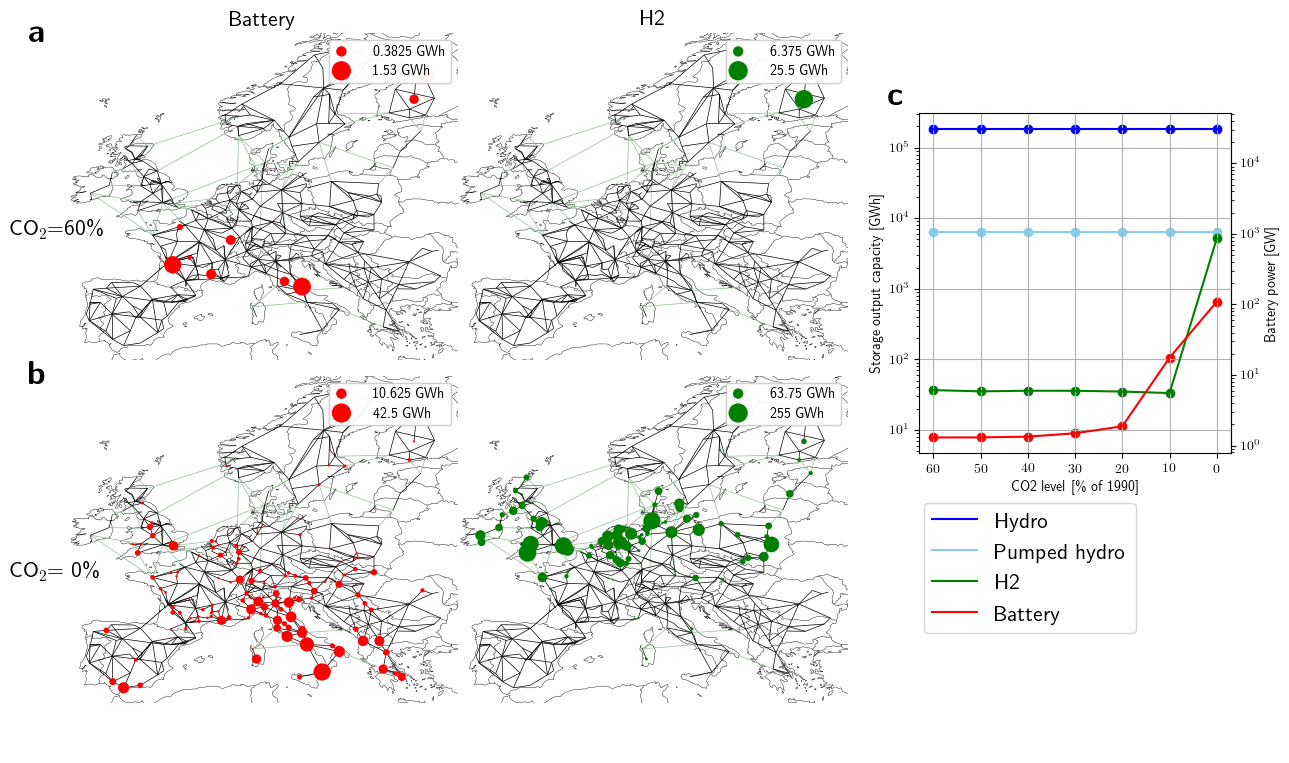

In [6]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [False, True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [0.6, 0.0]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(15,10))

       gs = GridSpec(1, 2, width_ratios=[2,0.8], wspace=0.13)
       gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs[0], wspace=-0.0, hspace=-0.2)
       gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs[1], height_ratios=[0.1,0.4,0.3])

       axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
              for i in range(2)] for j in range(2)])
       ax_line = f.add_subplot(gs_lines[1])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for j, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                                   f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[i,j])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     axs_maps[i,j].legend(loc="upper left")
                     pypsa.plot.add_legend_circles(axs_maps[i,j], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[0,j].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0,0].text(0 - 0.1, 1,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.1, 1,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       axs_maps[0,0].text(0 - 0.15, 0.4,
                     r'CO$_2$=60\% ',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.15, 0.4,
                     r'CO$_2$= 0\%',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{c}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                                          f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
              print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot([i*10 for i in range(7)][::-1] ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(4):
              plt.scatter([i*10 for i in range(7)][::-1] ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,j in enumerate(ax_line.lines):
              j.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[2])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
       ax_line_legend.axis("off")

       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacityvs_co2level"

       plt.savefig(save_path+file_name + '.pdf', bbox_inches='tight')

i tried to use the same node scaling for the different levels but didnt get it to work out...

In [7]:
# mpl.style.use('default')
# plt.rc('text', usetex=True)
# plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

# target_levels = [0.6, 0.0]

# f = plt.figure(figsize=(15,10))

# gs = GridSpec(1, 2, width_ratios=[2,0.8], wspace=0.13)
# gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs[0], wspace=-0.0, hspace=-0.2)
# gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs[1], height_ratios=[0.1,0.4,0.3])

# axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
#        for i in range(2)] for j in range(2)])
# ax_line = f.add_subplot(gs_lines[1])

# ##### panal a, b: maps #######

# buses = list(network.buses.index)
# storage_types = network.storage_units["carrier"].unique()
# multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

# battery_color = "red"
# h2_color = "green"
# for j, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
#        max_capacity_all_lvls = 0
#        for i, target_level in enumerate(target_levels[::-1]):
#               ax_current = axs_maps[1-i,j]
#               n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
#                             f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
#               # print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
#               storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
#               storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
#               max_node_size = 0.85
#               max_capacity = storage_capacities_grouped[:,current_store_type].max()
#               max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
#               max_capacity_all_lvls = max(max_capacity_all_lvls, max_capacity_rounded)
#               print(f"max capacity {target_level}, {current_store_type}: {max_capacity}")
#               print(f"max capacity all {target_level}, {current_store_type}: {max_capacity_all_lvls}")
#               n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_all_lvls*max_node_size/10e2,
#                      line_colors='black',
#                      bus_colors=current_color,
#                      link_widths=0.5,
#                      line_widths=0.5,
#                      ax=ax_current)
#               legend_relative_circle_size = np.array([0.25, 1])
#               legend_circle_size = [size*max_node_size*max_capacity/max_capacity_all_lvls/10e2 for size in legend_relative_circle_size]
#               ax_current.legend(loc="upper center")
#               pypsa.plot.add_legend_circles(axs_maps[i,j], sizes=legend_circle_size, labels=[f"{size*max_capacity:g} MW" for size in legend_circle_size], patch_kw={"color":current_color})
              
#               # for relative_size_r in [0.25, 1]:
#               #        axs_maps[i,j].plot(
#               #        [],
#               #        [],
#               #        marker="o",
#               #        color=current_color,
#               #        markersize=max_node_size * relative_size_r*10,
#               #        label=f"{int(max_capacity * relative_size_r)} MW",
#               #        lw=0,
#               #        )
#               # axs_maps[i,j].legend(
#               #        labelspacing=1,
#               #        loc="center left",
#               #        bbox_to_anchor=(0.7, 0.975),
#               #        frameon=False,
#               #        fontsize=14,
#               # )

#               # set current_store_type to upper case
#               current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
#               axs_maps[0,j].set_title(current_store_type_string, fontsize=16)
              
# axs_maps[0,0].text(0 - 0.1, 1,
#               r'\textbf{a}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=axs_maps[0,0].transAxes)
# axs_maps[1,0].text(0 - 0.1, 1,
#               r'\textbf{b}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=axs_maps[1,0].transAxes)


# axs_maps[0,0].text(0 - 0.15, 0.4,
#               r'CO$_2$=60\% ',
#               fontsize=16,
#               verticalalignment='center',
#               transform=axs_maps[0,0].transAxes)
# axs_maps[1,0].text(0 - 0.15, 0.4,
#               r'CO$_2$= 0\%',
#               fontsize=16,
#               verticalalignment='center',
#               transform=axs_maps[1,0].transAxes)


# ###### panel c: total capacity line plot #####

# ax_line.text(0 - 0.1, 1+0.05,
#               r'\textbf{c}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=ax_line.transAxes)

# capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
# for target_level in co2ls:
#     n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
#                             f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
#     print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
#     storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
#     storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
#     storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
#     capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

# capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
# try:
#        capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
# except:
#        pass
# capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
# ax_line.plot([i*10 for i in range(7)][::-1] ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
# secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
# secax.set_ylabel('Battery power [MW]')
# colors = ["blue", "skyblue", h2_color, battery_color]

# for i,j in enumerate(ax_line.lines):
#     j.set_color(colors[i])

# ax_line.invert_xaxis()
# ax_line.grid(True)
# plt.yscale('log')
# plt.ylabel("Storage capacity [MWh]")
# plt.xlabel(r"CO2 level [\% of 1990]")
# plt.legend()
# h, l = ax_line.get_legend_handles_labels()
# ax_line.get_legend().remove()
# ax_line_legend = f.add_subplot(gs_lines[2])
# ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
# ax_line_legend.axis("off")

# plt.savefig(save_path+'storage_capacity.pdf', bbox_inches='tight')

# Figure 4: inertia

In [8]:
inertia_time = np.load(path_to_pre_outage +
                       f'inertia_time_series_all_co2ls_{n_nodes}.npy')
inertia_generation = np.load(
    path_to_pre_outage + f'min_max_nodal_inertia_generation_all_co2ls_{n_nodes}.npy')


<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/794788486.py:70: SyntaxWarning: invalid escape sequence '\%'
  label=r'$\text{CO}_2\text{ level} =$ '+ '{} \% of 1990'.format(int(level*100)))


1619.4745183228827
271.6858748095594
878.442644303537
84.60615703485763


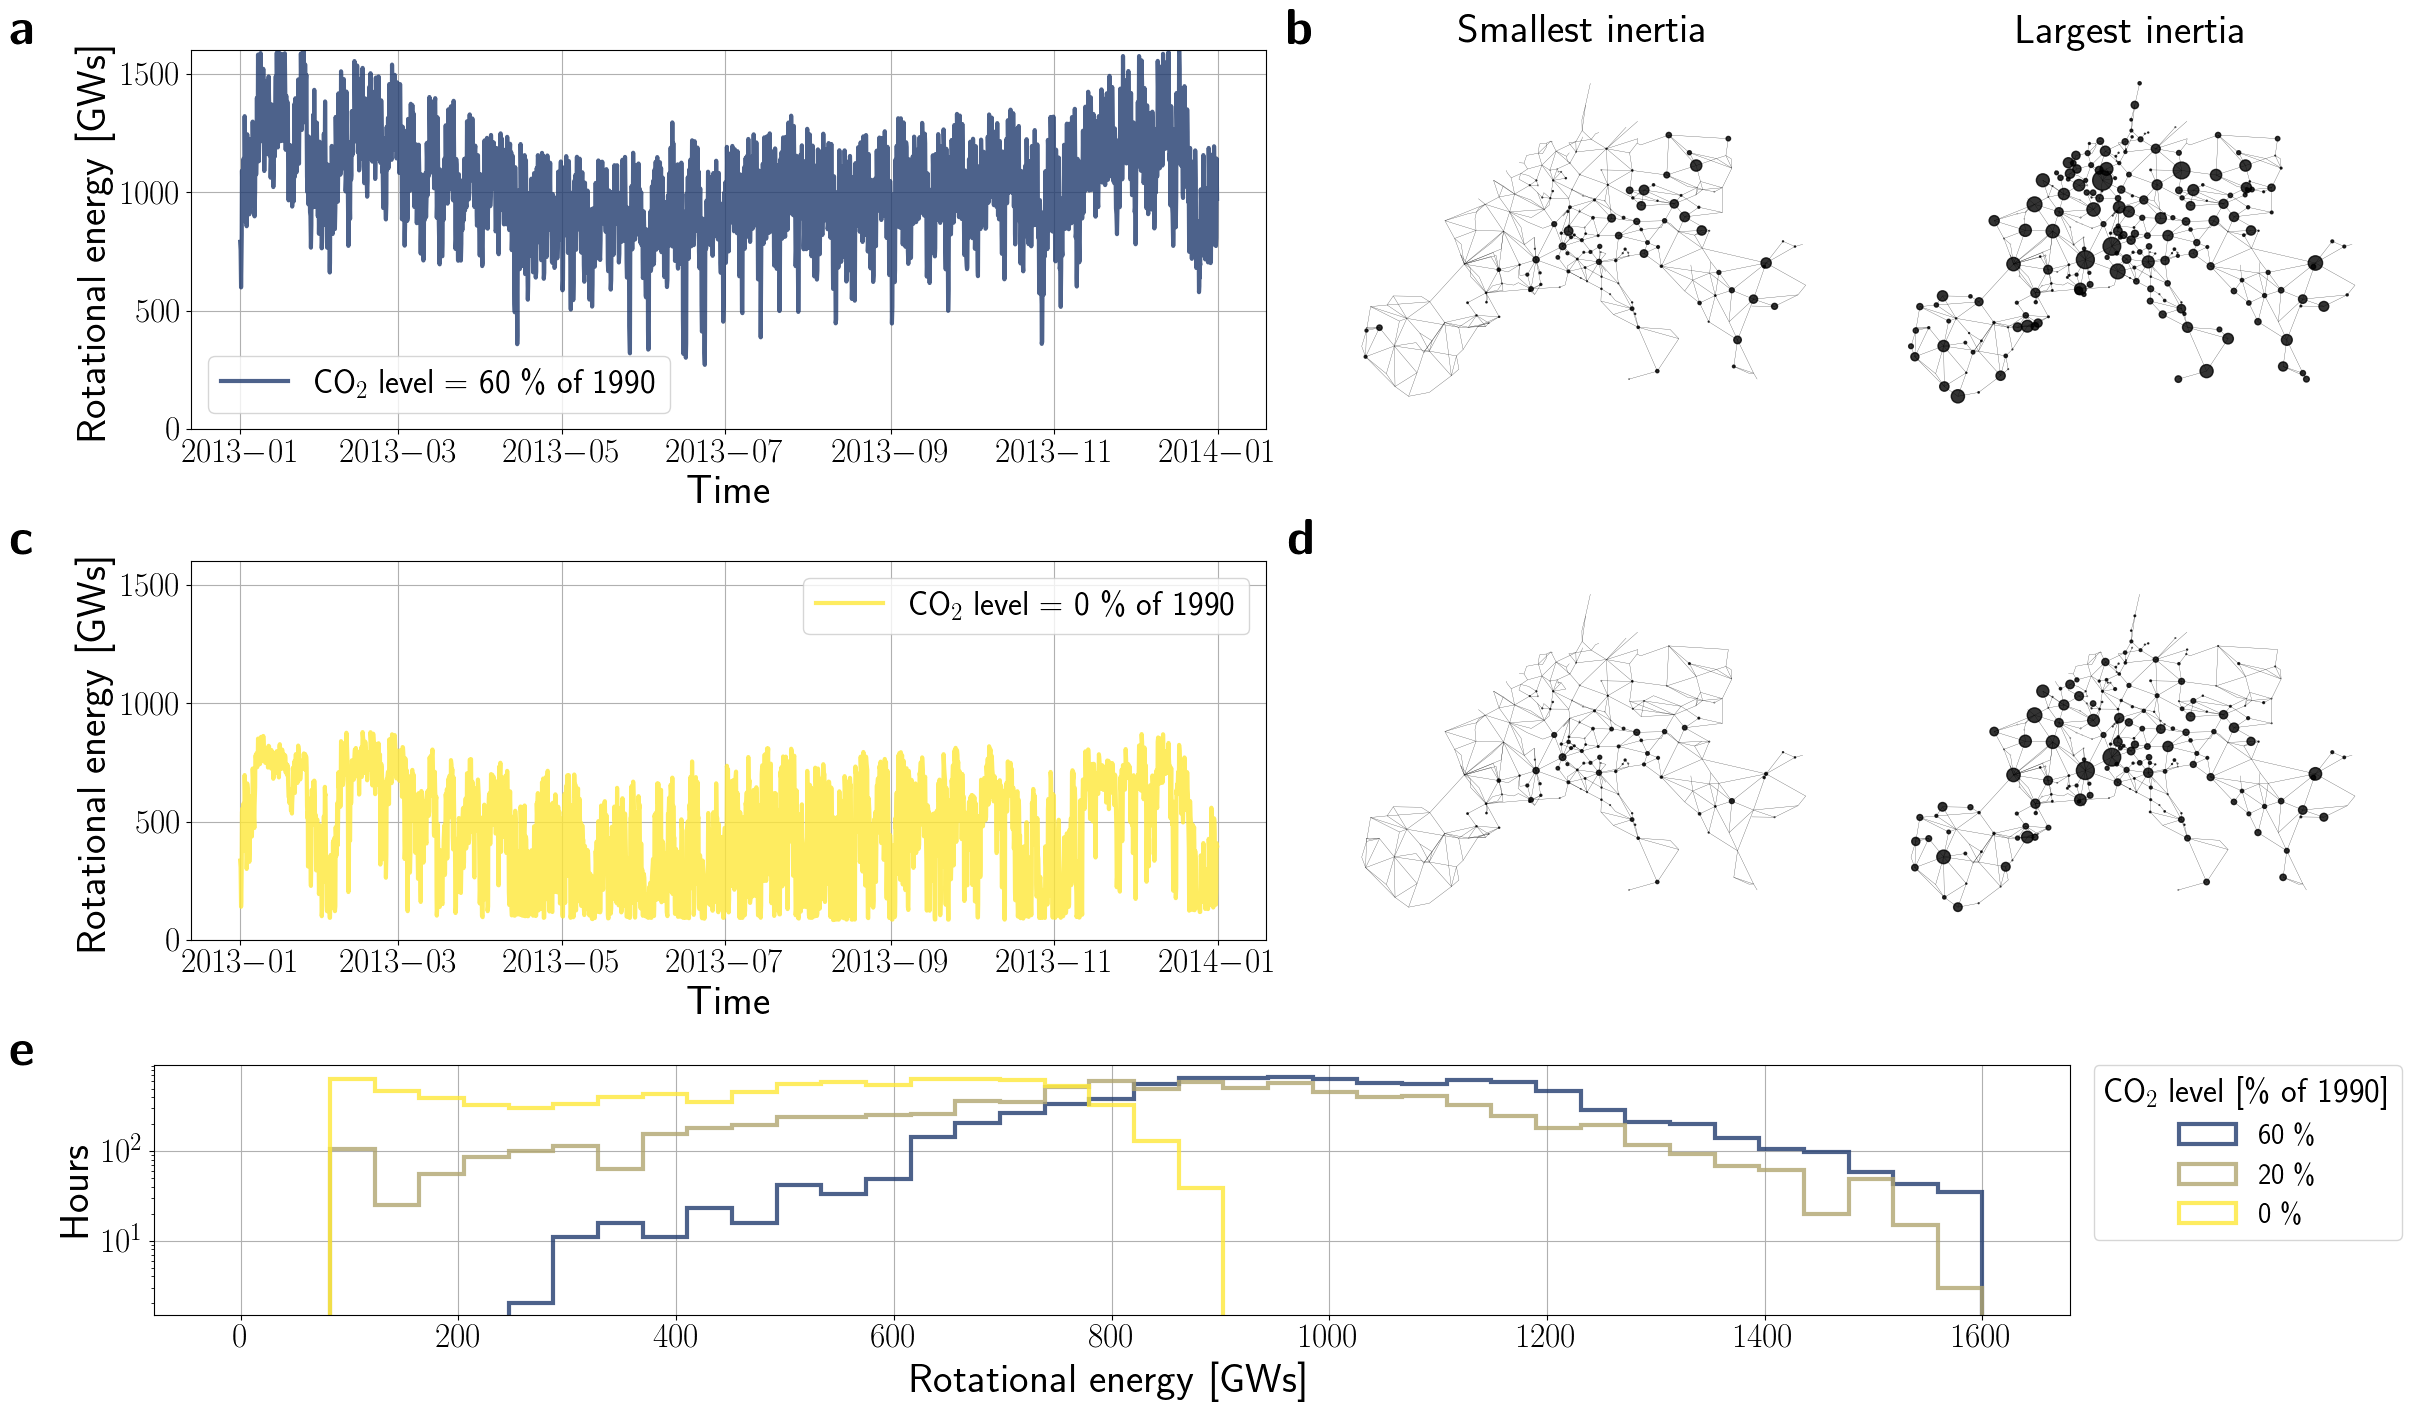

In [9]:
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}'], [r'\textbf{e}']]
f = plt.figure(figsize=(24, 14), constrained_layout=True)
gs_maps = GridSpec(3, 4, figure=f)
gs_probs = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_maps[2, :], width_ratios=[8, 1])
axs_probs_plot = f.add_subplot(gs_probs[0, 0])
axs_probs_legend = f.add_subplot(gs_probs[0, 1])
ax2 = f.add_subplot(gs_maps[0, :2])
ax3 = f.add_subplot(gs_maps[1, :2])
ax21 = f.add_subplot(gs_maps[0, 2])
ax22 = f.add_subplot(gs_maps[0, 3])
ax31 = f.add_subplot(gs_maps[1, 2])
ax32 = f.add_subplot(gs_maps[1, 3])
axs_primary = [[ax21, ax22], [ax31, ax32]]


########## panel  e: inertia histograms ############

cmap = plt.get_cmap('cividis_r')
bins = np.linspace(0, 1600, 40)

for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    # ax.hist(np.repeat(inertia_time[ind], network.snapshot_weightings.generators)/1000,
    axs_probs_plot.hist(inertia_time[ind]/1000,
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(level*100)),
            linewidth=3,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs_plot.xaxis.offsetText.set_fontsize(24)

leg = axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
h, l = axs_probs_plot.get_legend_handles_labels()
leg = axs_probs_legend.legend(h, l, borderaxespad=0, fontsize=20.5, title=r'CO$_2$ level [\% of 1990]')
# axs_probs_legend.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
axs_probs_legend.axis("off")
# leg=axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')

plt.setp(leg.get_title(),fontsize=24)
axs_probs_plot.tick_params(axis='both', which='both', labelsize=24)
axs_probs_plot.set_xlabel('Rotational energy [GWs]',  fontsize=30)
axs_probs_plot.set_ylabel('Hours', fontsize=30)
axs_probs_plot.set_yscale('log')
axs_probs_plot.grid()
axs_probs_plot.get_legend().remove()


############# panels a and c: inertia time series ################

axes = [ax2, ax3]

for j, level in enumerate(target_levels):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    print(np.amax(inertia_time[ind]/1000))
    print(np.amin(inertia_time[ind]/1000))
    axes[j].plot(network.snapshots,
                 inertia_time[ind]/1000,
                 color=cmap(ind/len(co2ls)),
                 lw=3,
                 alpha=0.8,
                 label=r'$\text{CO}_2\text{ level} =$ '+ '{} \% of 1990'.format(int(level*100)))
    axes[j].legend(fontsize=24)
    axes[j].tick_params(axis='both', which='both', labelsize=24)
    axes[j].set_ylabel('Rotational energy [GWs]', fontsize=30)
    axes[j].set_xlabel('Time', fontsize=30)
    axes[j].set_ylim([0, 1600])
    axes[j].yaxis.offsetText.set_fontsize(24)
    axes[j].grid()


########### panels b and d: maps with nodal inertia ###############

target_levels = [0.60, 0.00]
titles = ['Smallest inertia', 'Largest inertia']

for j, level in enumerate(target_levels):

    ind = np.where(co2ls == level)[0][0]
    
    for i in range(len(titles)):
        nx.draw_networkx_nodes(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               node_size=inertia_generation[ind, i]/300,
                               alpha=0.8,
                               node_color='black')
        nx.draw_networkx_edges(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               alpha=0.8,
                               width=0.2)
        if j == 0:
            axs_primary[j][i].set_title(titles[i], fontsize=30)
        axs_primary[j][i].axis('off')

# panel labels
ax3.text(0 - 2.25*0.075, 1+0.05,
         labels[1][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax2.text(0 - 2.25*0.075, 1+0.05,
         labels[0][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)
ax31.text(0 - 0.05, 1+0.05,
          labels[1][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
ax21.text(0 - 0.05, 1+0.05,
          labels[0][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax21.transAxes)
axs_probs_plot.text(0 - 0.075, 1+0.05,
        labels[2][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs_plot.transAxes)


plt.savefig(save_path+'total_system_inertia.pdf',bbox_inches = 'tight')


# Figure 3: SPI

In [10]:
mean_consumption_vector = np.load(
    path_to_pre_outage + f'mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
weighted_mean_consumption_vector = np.load(
    path_to_pre_outage + f'weighted_mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
dipole_vector = np.load(path_to_pre_outage +
                        f'dipole_vector_time_series_all_co2ls_{n_nodes}.npy')
vec_norm = np.load(path_to_pre_outage + f'spi_time_series_all_co2ls_{n_nodes}.npy')


<>:114: SyntaxWarning: invalid escape sequence '\%'
<>:114: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/2479679443.py:114: SyntaxWarning: invalid escape sequence '\%'
  label='{} \%'.format(int(level*100)),


Figure 3


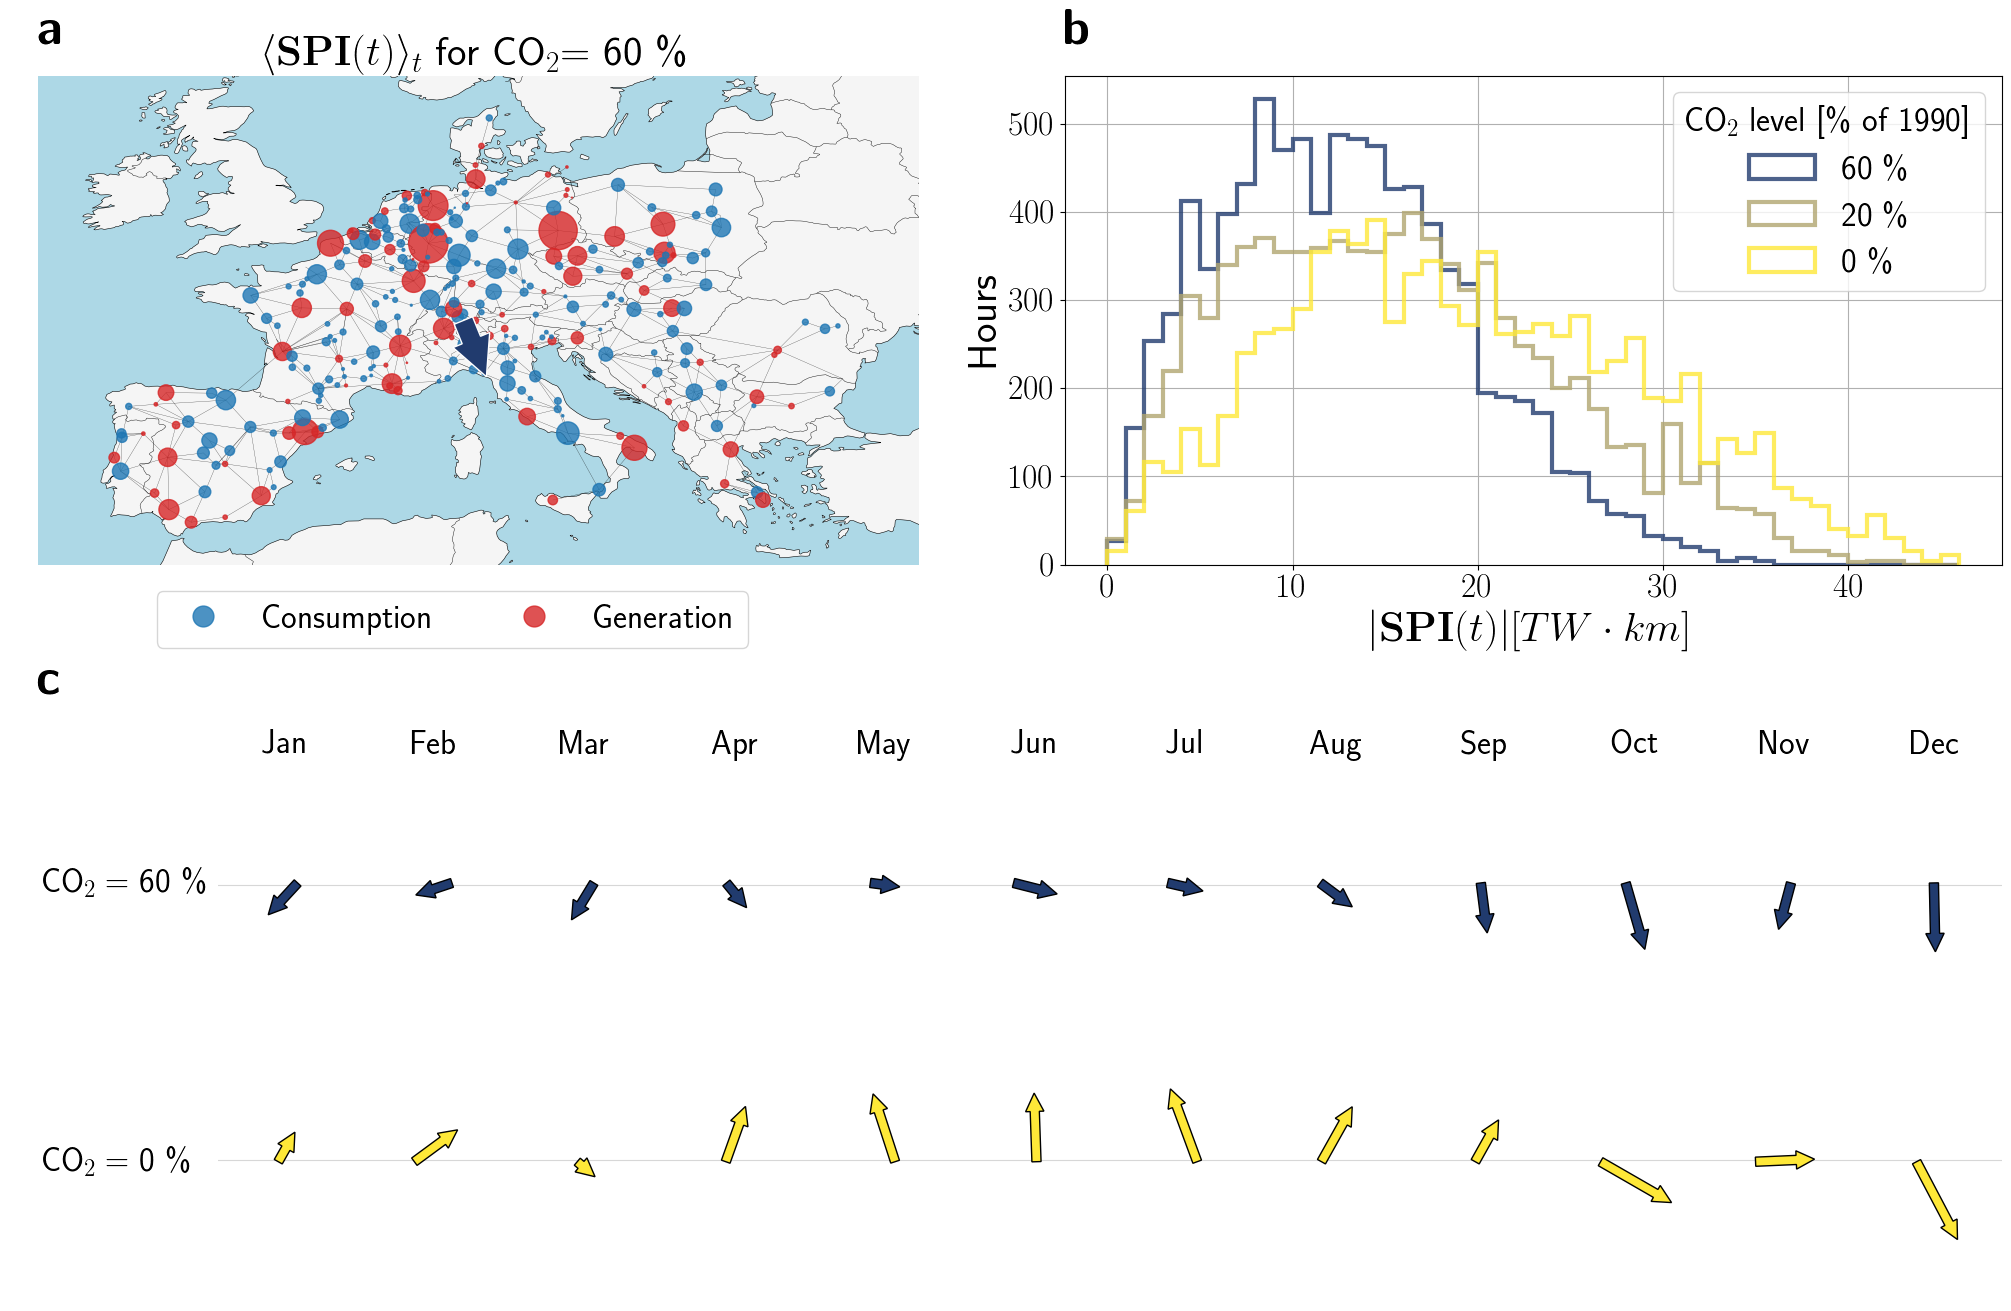

In [11]:
print("Figure 3")

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs1[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs1[1])
gs2 = GridSpecFromSubplotSpec(2, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
axs_co2_0 = f.add_subplot(gs2[0, 0])
axs_co2_1 = f.add_subplot(gs2[1, 0])
axs_co2_0.axis('off')
axs_co2_1.axis('off')

axs_primary = [f.add_subplot(gs2[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs_secondary = [f.add_subplot(gs2[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 60% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis_r')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)

vec = weighted_mean_consumption_vector
plot_co2ls = [0.6]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls[::-1]):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(level*100)),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0

for j in range(12):

    new_ind = old_ind + \
        len(network.snapshots[network.snapshots.month == int(j+1)])

    current_level = 0.6
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    # for mean use np.average with weights

    axs_primary[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))


    current_vec = np.median(dipole_vector[:, :, old_ind:new_ind], axis=2) # maybe take mean?!
    
    current_level = 0.0
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!

    axs_secondary[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))
    
    
    axs_primary[j].axis('off')
    axs_secondary[j].axis('off')
    
    axs_primary[j].set_ylim([31.707498915424157, 60.29928495567561])
    axs_secondary[j].set_ylim([31.707498915424157, 60.29928495567561])

    old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs2[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

axs_co2_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_co2_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
axs_co2_0.text(0.25, 0.5, r'CO$_2 =$ 60 \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, r'CO$_2 =$ 0 \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 60 \%', fontsize=30)


for j in range(12):
    axs_primary[j].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
plt.savefig(save_path+'inital_grid_situation.pdf',bbox_inches = 'tight')

# Figure 7: line failures

## split likelihood

Note: These are the likelihoods for ANY split that occured, i.e., also those with only 1 or 2 nodes being split off. Should we keep it like this?

Important: When setting vmin larger then the minimum probability, then edges with likelihood below vmin appear as gray, which might be confused with a line that never leads to a blackout. So: Check vmin/vmax configuration and maybe explain in figure legend. 

In [12]:
edge_likelihoods_primary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_primary_all_co2ls_n{n_nodes}.pickle', 'rb'))
edge_likelihoods_secondary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_secondary_all_co2ls_n{n_nodes}.pickle', 'rb'))


<>:107: SyntaxWarning: invalid escape sequence '\%'
<>:107: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/1714210326.py:107: SyntaxWarning: invalid escape sequence '\%'
  axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
/tmp/ipykernel_20855/1714210326.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


Min val prim: 4.986506e-08
Max val prim: 4.479777e-04
Min val prim: 9.973012e-09
Max val prim: 5.787680e-04
Min val prim: 1.662169e-09
Max val prim: 6.760979e-04


/tmp/ipykernel_20855/1714210326.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))


Min val sec: 1.662169e-09
Max val sec: 6.573295e-04
Min val sec: 1.662169e-09
Max val sec: 8.399645e-04
Min val sec: 1.662169e-09
Max val sec: 1.520954e-03
0.001 1e-05


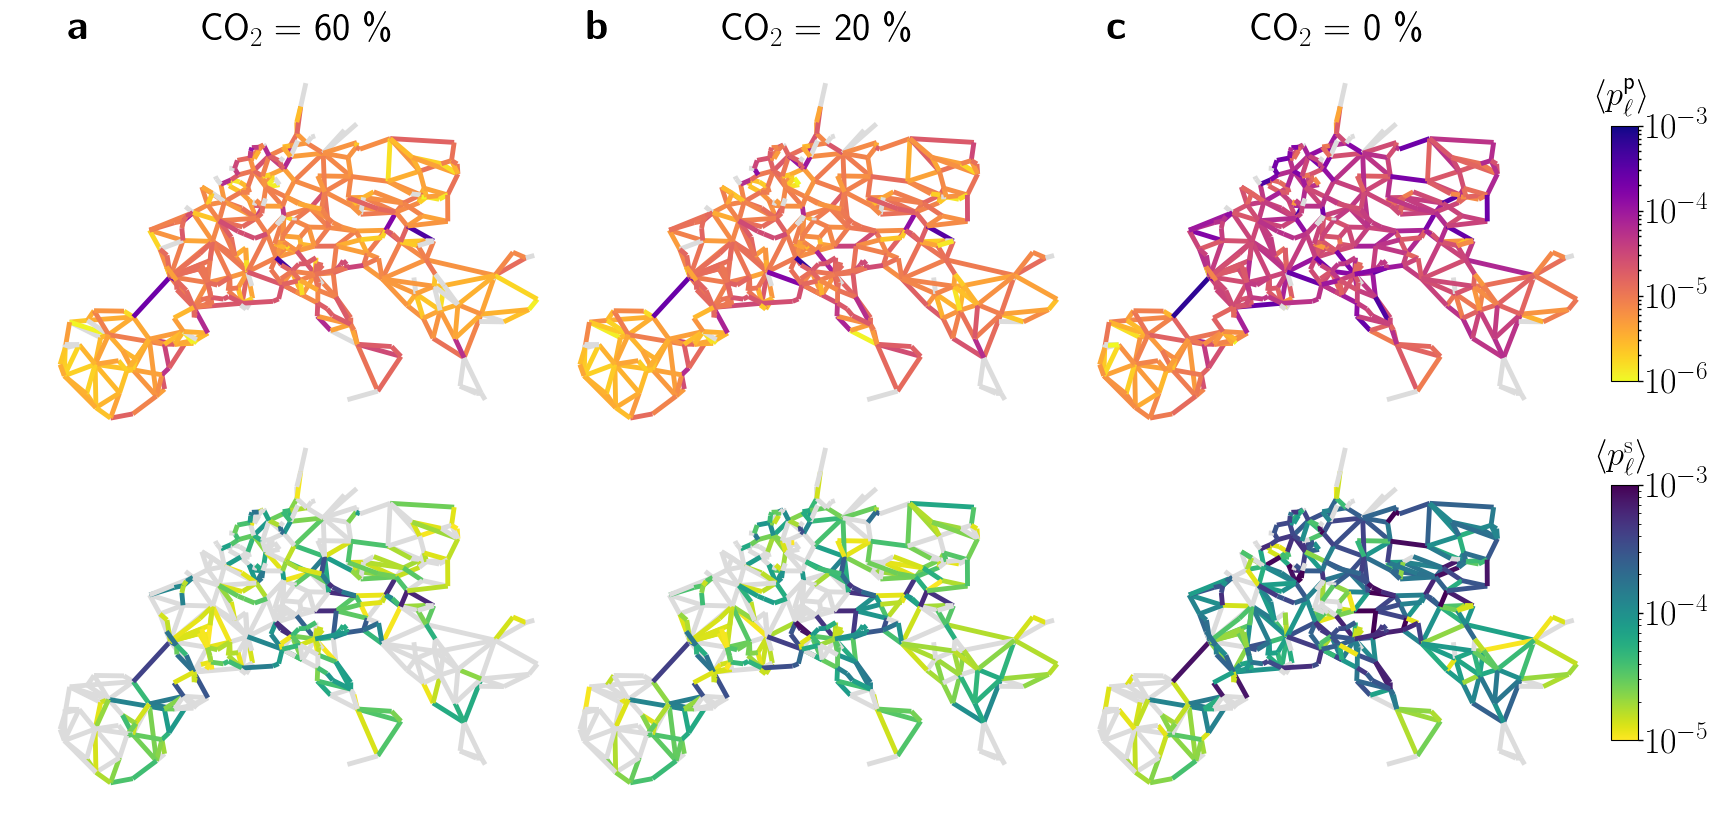

In [13]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    vmax = 1e-3
    # vmax = 10**max(c_H_p_log)
    vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    vmax = 1e-3
    vmin = 1e-5
    vmaxvals.append(vmax)
    vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   edge_color=c_H_s_log,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=np.log10(vmin),
                                   edge_vmax=np.log10(vmax))

    axs_secondary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
    axs_primary[count].text(0+0.1, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)


# cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[1])
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# cb.ax.yaxis.set_ticks([1e-6,1e-4,1e-2,1])

# minortcs = np.arange(1,10,1)
# minortcs = np.array([minortcs*1e-7,minortcs*1e-6,minortcs*1e-5,minortcs*1e-4,minortcs*1e-3]).flatten()
# minortcs = minortcs[(minortcs>vmin) & (minortcs<vmax)]
# cb.ax.yaxis.set_ticks(minortcs, minor=True)

print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'line_failure_probs.pdf',bbox_inches = 'tight')

inspect ration between primary and secondary failure probabilities

/tmp/ipykernel_20855/4090611089.py:4: RuntimeWarning: invalid value encountered in divide
  ratio = c_H_s/c_H_p


(array([344., 102.,  41.,  12.,   8.,   4.,   7.,   3.,   1.,   1.]),
 array([ 0.        ,  4.33719457,  8.67438913, 13.0115837 , 17.34877826,
        21.68597283, 26.02316739, 30.36036196, 34.69755653, 39.03475109,
        43.37194566]),
 <BarContainer object of 10 artists>)

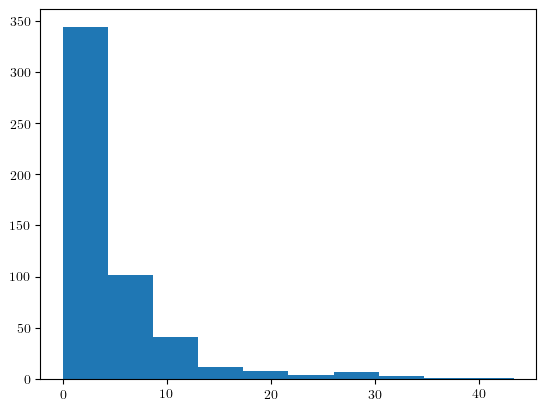

In [14]:
level = 0.0
c_H_p = np.array([edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()])
c_H_s = np.array([edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()])
ratio = c_H_s/c_H_p
plt.hist(ratio)#, bins=np.logspace(-3, 3, 50))

Min val prim: 3.707824e-04
Max val prim: 1.154054e+02
Min val prim: 2.650762e-04
Max val prim: 5.697570e+01
Min val prim: 2.947745e-03
Max val prim: 4.337195e+01


/tmp/ipykernel_20855/92509153.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


Text(0.5, 1.0, '$\\langle p_{\\ell}^{\\text{p}}\\rangle$')

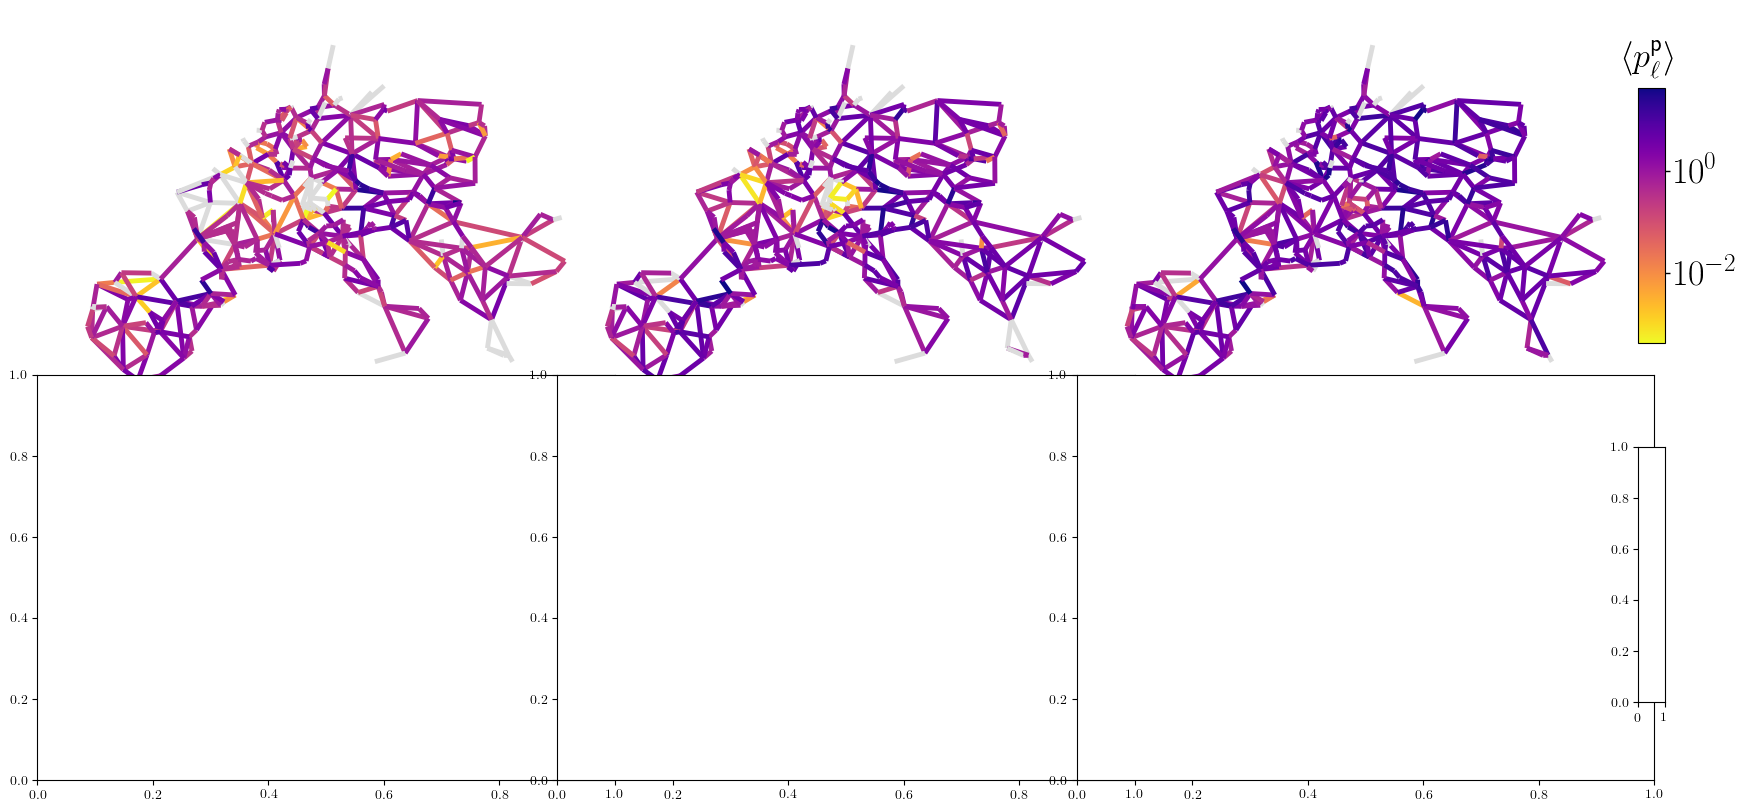

In [15]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_sec = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p = [a/b if b!=0 else 0 for a,b in zip(c_H_p_sec,c_H_p)]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    # vmax = 1e-3
    # # vmax = 10**max(c_H_p_log)
    # vmin =  1e-6
    vmax = 10**max(c_H_p_log)
    vmin =  vmax * 1e-5

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

# ###### Secondary failures #####

# cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
# cmap.set_under('gainsboro', 1.0)

# for count, co2l in enumerate(selected_co2ls[::-1]):

#     level = np.round(co2l, 2)
    
#     # Load likelihoods as dictionary and transform into array
#     c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
#     c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
#     print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     # vmax = 1e-3
#     # vmax = 10**max(c_H_s_log)
#     vmax = 1e-3
#     vmin = 1e-5
#     vmaxvals.append(vmax)
#     vminvals.append(vmin)

#     nodes = nx.draw_networkx_nodes(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    node_color='black',
#                                    node_size=0)

#     edges = nx.draw_networkx_edges(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    edge_color=c_H_s_log,
#                                    width=3.5,
#                                    edge_cmap=cmap,
#                                    edge_vmin=np.log10(vmin),
#                                    edge_vmax=np.log10(vmax))

#     axs_secondary[count].axis('off')

#     axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
#     axs_primary[count].text(0+0.1, 1+0.05,
#                     labels[count],
#                     fontsize=30,
#                     weight='bold',
#                     verticalalignment='center',
#                     transform=axs_primary[count].transAxes)


# # cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
# sm = plt.cm.ScalarMappable(
#     cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# cb = f.colorbar(sm, cax=axs_colorbars[1])
# # cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
# cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
# cb.ax.tick_params(labelsize=26, width=1.0, which='major')
# axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
#              fontsize=25,
#              weight='bold',
#              verticalalignment='center',
#              pad=20)
# cb.ax.yaxis.set_ticks([1e-6,1e-4,1e-2,1])

# minortcs = np.arange(1,10,1)
# minortcs = np.array([minortcs*1e-7,minortcs*1e-6,minortcs*1e-5,minortcs*1e-4,minortcs*1e-3]).flatten()
# minortcs = minortcs[(minortcs>vmin) & (minortcs<vmax)]
# cb.ax.yaxis.set_ticks(minortcs, minor=True)

# print(np.max(vmaxvals), np.min(vminvals))


# plt.savefig(save_path+'fig7.pdf',bbox_inches = 'tight')

## loss of load

In [16]:
try:
    with open(path_to_vis_results + f'loss_by_trigger_lvls.pickle', 'rb') as f:
        loss_by_trigger_lvls = pickle.load(f)
except FileNotFoundError:
    loss_by_trigger_lvls = {}
    for co2l in selected_co2ls:
        split_significance = pd.read_csv(path_to_evaluation_results + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        trigger0 = split_significance.loc[:,["lost_load_rocof_share","init_failures_0"],].groupby("init_failures_0").sum()
        trigger1 = split_significance.loc[:,["lost_load_rocof_share","init_failures_1"],].groupby("init_failures_1").sum()
        trigger1.rename_axis("trigger", inplace=True)
        trigger0.rename_axis("trigger", inplace=True)
        loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
        loss_by_trigger.rename_axis("trigger", inplace=True)
        loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_rocof_share, fill_value=0)
        loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_rocof_share, fill_value=0)
        
        loss_by_trigger_lvls[co2l] = loss_by_trigger

    with open(path_to_vis_results + f'loss_by_trigger_lvls.pickle', 'wb') as f:
        pickle.dump(loss_by_trigger_lvls, f, protocol=pickle.HIGHEST_PROTOCOL)

<>:49: SyntaxWarning: invalid escape sequence '\%'
<>:49: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/1513671617.py:49: SyntaxWarning: invalid escape sequence '\%'
  axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
/tmp/ipykernel_20855/1513671617.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


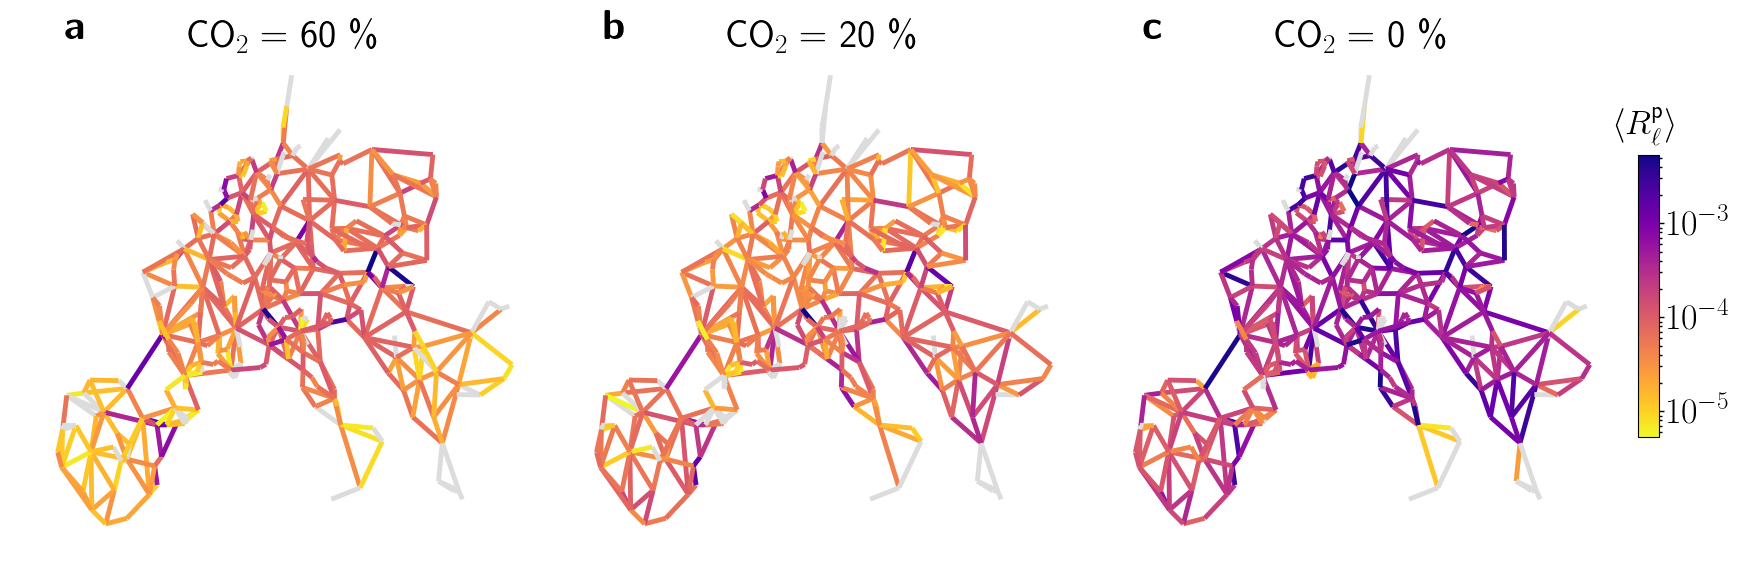

In [17]:
##### setup figure #####
f = plt.figure(figsize=(21, 7.05))
gs = GridSpec(1, 3, figure=f, width_ratios=[1,1,1], wspace=-0.02)
axs_primary = [f.add_subplot(gs[i]) for i in range(3)]
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under("gainsboro", 1.0)

# alternative to set values have only bridges in grey
# cmap.set_under(cmap(0), 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    loss_per_failure = loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)
    loss_log_per_failure = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in loss_per_failure])
    
    # alternative to set values have only bridges in grey
    # log_min = np.log10(np.min(loss_per_failure[loss_per_failure!=0]))
    # loss_log_per_failure = np.array([np.log10(x) if x > log_min else -np.inf for x in loss_per_failure])
    
    vmax = 10**max(loss_log_per_failure)
    vmin =  vmax * 1e-3

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=loss_log_per_failure,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
    axs_primary[count].text(0+0.1, 1,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# add colorbar axis
axs_colorbars = [f.add_axes([0.9, 0.3, 0.01, 0.4])]
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(
                        #    r'$\langle L_{\ell}\rangle$',
                           r'$\langle R_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# plt.tight_layout()
plt.savefig(save_path+'loss_by_trigger_map.pdf',bbox_inches = 'tight')

# Nodal Blackout Prob

In [18]:
from utils.config import path_to_indicator_vectors
import gzip
from utils.clustering_visualisation import truncate_colormap
from utils.alternative_split_indicator_vectors import get_indicator_vector_snapshot_weightings

In [19]:
try:
    
    with open(path_to_evaluation_results + f"blackout_prob_dict_n{n_nodes}.pickle", "rb") as out:
        blackout_prob_dict = pickle.load(out)
    with open(path_to_evaluation_results + f"edge_failure_prob_dict_n{n_nodes}.pickle", "rb") as out:
        edge_failure_prob_dict = pickle.load(out)
        
except FileNotFoundError:
    blackout_prob_dict = {}
    edge_failure_prob_dict = {}
    vmin_node = 1
    vmax_node = 0
    for target_level in selected_co2ls:
        print(target_level)
        
        path = (
                path_to_indicator_vectors
                + f"/indicator_vector_rocof_Co2l{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            rocof_indicator_vectors = pickle.load(out)[-1]
        path = (
                path_to_indicator_vectors
                + f"/indicator_vector_failed_edges_Co2l{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            failed_edges_indicator_vectors = pickle.load(out)[-1]

        weights = get_indicator_vector_snapshot_weightings(target_level)
        print(weights.shape, rocof_indicator_vectors.shape, failed_edges_indicator_vectors.shape)
        blackout_prob_dict[target_level] = (weights.reshape(1,-1) @  (rocof_indicator_vectors<-1)).squeeze()/num_failures_weighted
        
        edge_failure_prob_dict[target_level] = (weights.reshape(1,-1) @  failed_edges_indicator_vectors).squeeze()/num_failures_weighted
        
    with open(path_to_evaluation_results + f"blackout_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(blackout_prob_dict, out)
    with open(path_to_evaluation_results + f"edge_failure_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(edge_failure_prob_dict, out)


<>:92: SyntaxWarning: invalid escape sequence '\%'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\%'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
<>:117: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_20855/1631634900.py:92: SyntaxWarning: invalid esca

level: 0.6
0.0004519461551761443
4.238530113659425e-08
level: 0.2
0.00047006711803854244
4.2103563546686326e-05
level: 0.0
0.0009784214603528055
0.0004163375157153894


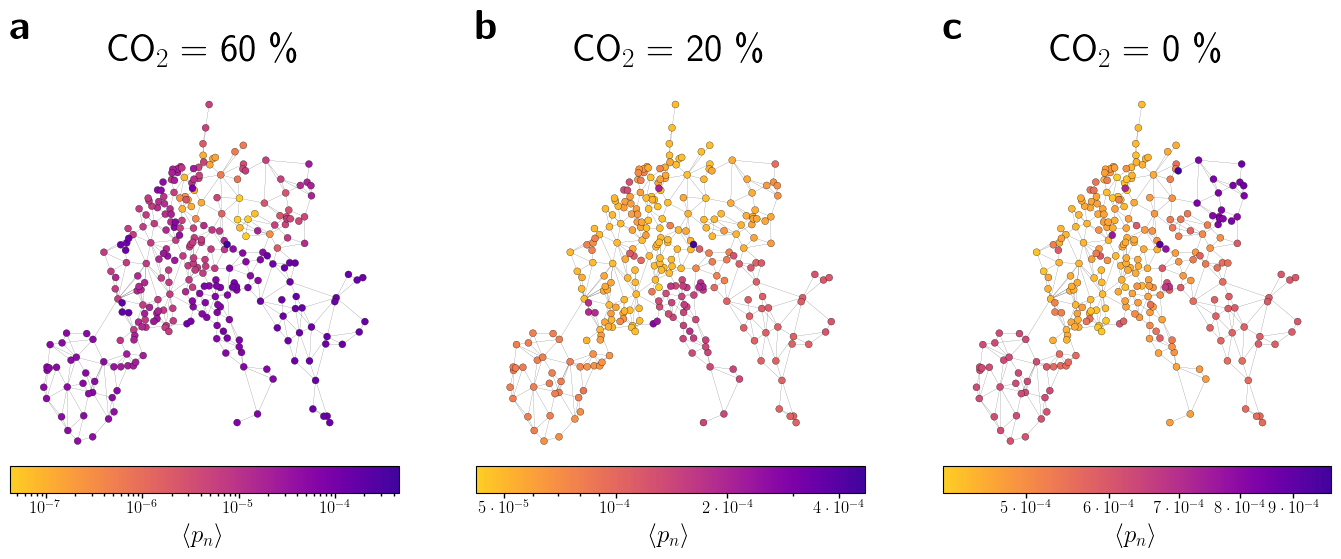

In [20]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize=(15.5*1.1, 5*1.1))

gs_maps = GridSpec(1, len(selected_co2ls), figure=f)
gs_lvls = []
for i, target_level in enumerate(selected_co2ls):
    gs_lvl = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_maps[0, i], height_ratios=[15, 1], hspace=-0.05)
    gs_lvls.append(gs_lvl)

labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

node_cmap = plt.get_cmap('plasma_r')
node_cmap = truncate_colormap(node_cmap, 0.1, 0.9, 1000)
node_cmap.set_under('gainsboro', 1.0)
node_cbar_label="blackout prob"

# vmax_node = -np.inf
# vmin_node = np.inf
# vmaxes = []

# for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
#     ax = f.add_subplot(gs_lvl[0])
#     ax_cbar = f.add_subplot(gs_lvl[1])

#     blackout_prob = blackout_prob_dict[target_level]
#     edge_failure_prob = edge_failure_prob_dict[target_level]
    
#     blackout_prob_log = np.array(
#         [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
#     )
#     # vmax_node = blackout_prob.max()
#     # vmin_node = blackout_prob.min()
#     vmax_node = max(10**blackout_prob_log.max(), vmax_node)
#     vmin_node = min(10**blackout_prob_log.min(), vmin_node)
    
#     vmaxes.append(vmax_node)
#     # vmin_node = 10**blackout_prob_log.min()

# vmin_node = vmaxes[0]*1e-3

# vmin_node = 1e-4

for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
    ax = f.add_subplot(gs_lvl[0])
    ax_cbar = f.add_subplot(gs_lvl[1])

    blackout_prob = blackout_prob_dict[target_level]
    edge_failure_prob = edge_failure_prob_dict[target_level]
    
    blackout_prob_log = np.array(
        [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
    )
    # vmax_node = blackout_prob.max()
    # vmin_node = blackout_prob.min()
    vmax_node = 10**blackout_prob_log.max()
    vmin_node = 10**blackout_prob_log.min()

    # vmin_node = vmax * 10e-1
    print(f"level: {target_level}")
    print(vmax_node)
    print(vmin_node)
    # vmax_node = 10e-1
    # vmin_node = 10e-8

    nodes = nx.draw_networkx_nodes(
        nx_graph,
        pos=pos,
        ax=ax,
        node_size=25,
        node_color=blackout_prob_log,
        cmap=node_cmap,
        vmax=np.log10(vmax_node),
        vmin=np.log10(vmin_node),

    )
    nodes.set_edgecolor("black")
    nodes.set_linewidth(0.2)

    edges = nx.draw_networkx_edges(
        nx_graph,
        pos=pos,
        ax=ax,
        width=0.1,
        edge_color="black",
    )
    
    ax.set_title(r'CO$_2 =$ ' + '{} \%'.format(int(target_level*100)), fontsize=28)
    ax.text(0, 1+0.1,
                    labels[i],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)
    
    # ax.set_title(f"CO2={int(target_level*100)}%", fontsize=24)
    ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=node_cmap, norm=mplcolors.LogNorm(vmin=vmin_node, vmax=vmax_node))
    cb = f.colorbar(sm, cax=ax_cbar, orientation="horizontal")
    if target_level==0.0:
        # ticks = ax_cbar.get_xticks()
        # ax_cbar.set_xticks(ticks, labels=["" for i in range(len(ticks))])
        ax_cbar.set_xticks([i*1e-4 for i in range(5,10)], labels=["$5\cdot 10^{-4}$", "$6\cdot10^{-4}$","$7\cdot 10^{-4}$","$8\cdot 10^{-4}$", "$9\cdot 10^{-4}$"])
        # ax_cbar.xaxis.set_minor_locator(plt.LogLocator(base=10, numticks=1))
        pass
        
        # ax_cbar.set_xticks([0.5,1], labels=["0.5","1"])
        # ax_cbar.set_xticklabels(["0.5","1"])
    elif target_level==0.2:
        # ax_cbar.xaxis.set_minor_locator(plt.LogLocator(base=10, numticks=4))
        ax_cbar.set_xticks([5e-5,1e-4,2e-4,4e-4], labels=["$5\cdot 10^{-5}$", "$10^{-4}$","$2\cdot 10^{-4}$","$4\cdot 10^{-4}$"])
    ax_cbar.set_xlabel(r'$\langle p_{n}\rangle$', fontsize=18, labelpad=5)
    ax_cbar.tick_params(labelsize=12, width=1.0, which='both')
    

f.savefig(save_path+'nodal_blackout_prob.pdf',bbox_inches = 'tight')

# Figure 5: split statistics

In [21]:
# co2ls = np.arange(0.1,0.81,0.1).round(1)
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])

# Load split component properties
component_props = pd.read_hdf(path_to_vis_results + 'component_properties_all_n400.h5')
component_props.time_stamp = pd.to_datetime(component_props.time_stamp)
# indicator_vectors = np.load(path_to_vis_results + f'indicator_vectors_all_n400.npy').astype(bool)
split_props = pd.read_hdf(path_to_vis_results + 'split_properties_all_n400.h5')
# split_vectors = np.load(path_to_vis_results + f'split_vectors_all_n400.npy')


In [22]:
#TODO: remove this when all splits were evaluated!!!
# Restricting analysis to minimum of available time steps

# n_steps_to_consider = component_props.groupby('co2l').apply(lambda x:x.time_stamp.unique().shape[0]).min()
# number_of_simulations = n_steps_to_consider*len(n_2_failures)
# component_props = component_props[pd.to_datetime(component_props.time_stamp)<network.snapshots[n_steps_to_consider]]
component_props["snapshot_weighting"] = network.snapshot_weightings.generators[component_props.time_stamp].values
# indicator_vectors = indicator_vectors[:component_props.shape[0]]

# split_props = split_props[pd.to_datetime(split_props.index.get_level_values('time_stamp'))<network.snapshots[n_steps_to_consider]]
# split_vectors = split_vectors[:split_props.shape[0]]

# n_steps_to_consider


split_props["snapshot_weighting"] = network.snapshot_weightings.generators[split_props.index.get_level_values(1)].values
weighted_split_props_dict = dict({co2l:{category: split_props.loc[(split_props.category==category) & (split_props.index.get_level_values(0)==co2l), "snapshot_weighting"].sum() for category in split_props.category.unique()} for co2l in co2ls})
# for index,row in split_props.iterrows():
#         weighted_split_props_dict[index[0]][row.category] += row.snapshot_weighting

* **negligible**: there is a component with with >99% load that survives
* **relevant split without blackout/ Non-severe**: Not negligible and not blackout.
* **locally severe/ local blackout**: blackout of <99% of CE load
* **globally severe/ global blackout**: Blackout of >99% of CE load.




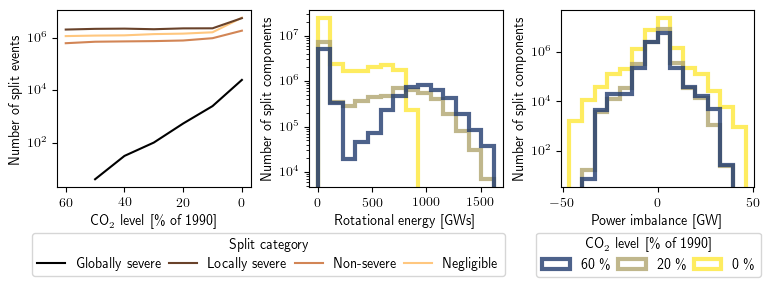

In [23]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

fig = plt.figure(figsize=(9, 3.3))
gs = GridSpec(2, 1, figure=fig, hspace=0.6, height_ratios=[1,0.1])


# Panel a: split number and categories
gsTop = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0,:], hspace=0, width_ratios=[1,1,1], wspace=0.3)
gs_bottom = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1,:], width_ratios=[2,1])
ax1 = fig.add_subplot(gsTop[0])
ax1_legend = fig.add_subplot(gs_bottom[0])

data0 = pd.DataFrame(weighted_split_props_dict).transpose()

data0 = data0.reindex(columns=['global_blackout', 'local_blackout', 'no_blackout', 'negligible'])
data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
                            'no_blackout':'Non-severe','negligible':'Negligible'})
data0 = data0.iloc[:, ::-1]

N = data0.shape[1]
cc = plt.cycler("color", plt.cm.copper_r(np.linspace(0,1,N)))

for d, col in zip(cc, data0.columns):
    data_series = data0[col]
    data_series[data_series==0.0] = np.nan
    data_series = data0[col].dropna()
    ax1.plot(data_series.index*100, data_series.values, color=d["color"], label=col)

ax1.set_yscale('log')
ax1.set_xlabel(r'CO$_2$ level [\% of 1990]')
ax1.set_ylabel('Number of split events')
ax1.invert_xaxis()

# Legend
# fig.tight_layout()
h, l = ax1.get_legend_handles_labels()
# ax1.get_legend().remove()
ax1_legend.legend(h[::-1], l[::-1], title='Split category', loc='center', ncols=4, columnspacing=0.5)
ax1_legend.axis("off")
# ax1.get_legend().remove()


# Panel b: Inertia histograms
cmap = plt.get_cmap('cividis_r')

ax2 = fig.add_subplot(gsTop[1])
ax2_legend = fig.add_subplot(gs_bottom[1])
rot_energy = component_props.rot_energy/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
for co2l in selected_co2ls:
    ax2.hist(rot_energy[component_props.co2l==co2l],
            weights=component_props.snapshot_weighting[component_props.co2l==co2l],
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(100*co2l)),
            linewidth=3,
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax2.set_yscale('log')
ax2.set_xlabel('Rotational energy [GWs]')
ax2.set_ylabel('Number of split components')

# Panel c: power imbalance histograms

ax3 = fig.add_subplot(gsTop[2])
rot_energy = component_props.power_imbalance/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
chandles = []
for co2l in selected_co2ls:
    h= ax3.hist(rot_energy[component_props.co2l==co2l],
            weights=component_props.snapshot_weighting[component_props.co2l==co2l],
            bins=bins,
            histtype='step',
            linewidth=3,
            label=r'{} \%'.format(int(100*co2l)),
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax3.set_yscale('log')
ax3.set_ylabel('Number of split components')
ax3.set_xlabel('Power imbalance [GW]')


# # Panel d: Load share strip plots

# # ax4 = fig.add_subplot(gs[1, 2])
# ax4 = fig.add_subplot(gsTop[0, 2])
# data = component_props.copy()
# # duplicate rows according to snapshot weighting
# data_duplicates = pd.concat([data[data.snapshot_weighting==weight] for weight in data.snapshot_weighting.unique() for i in range(int(weight))])
# # data_duplicates.loc[:,'Component blackout'] = data_duplicates.loc[:,'rocof']<-1
# data_duplicates = data_duplicates[data_duplicates.co2l<=0.6]
# cmap = plt.get_cmap('plasma_r')
# cmap.set_under('gainsboro', 1.0)
# hist = ax4.hist2d(data_duplicates.co2l, data_duplicates.load_share,cmap=cmap, alpha=1, norm=mpl.colors.LogNorm(), bins=(7,20))
# cbar = plt.colorbar(hist[3])
# cbar.set_label('Count')
# left, right = ax4.get_xlim()
# width = right - left
# bar_width = width / len(data_duplicates.co2l.unique())
# ax4.set_xticks([bar_width/2 + bar_width*i for i in range(len(data_duplicates.co2l.unique()))], labels=[f"{int(100*co2)}" for co2 in co2ls])
# ax4.set_yticklabels((ax4.get_yticks()*100).astype(int))
# ax4.set_ylabel(r'Load share [\%]')
# ax4.set_xlabel(r'CO$_2$ level [\% of 1990]')
# ax4.set_xticklabels((100*co2ls).astype(int))
# ax4.invert_xaxis()
# h, l = ax4.get_legend_handles_labels()
# ax4.legend(h,[r'$|$RoCoF$|$ $<$ 1 Hz/s', r'$|$RoCoF$|$ $>$ 1 Hz/s'], bbox_to_anchor=(0.85,-0.35), title='Split components with')

# h, l = ax4.get_legend_handles_labels()
h, l = ax2.get_legend_handles_labels()
# ax1.get_legend().remove()
ax2_legend.legend(h[::-1], l[::-1], title=r'CO$_2$ level [\% of 1990]', loc='center', ncols=3, columnspacing=0.5)
ax2_legend.axis("off")
# ax2.legend(bbox_to_anchor=(1,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')

# plt.tight_layout()
plt.savefig(save_path+'split_statistics.pdf',bbox_inches = 'tight')

# plt.show()

old plot with heatmap

In [24]:
# mpl.style.use('default')
# plt.rc('text', usetex=True)
# plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

# fig = plt.figure(figsize=(8, 5))
# gs_maps = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.45)


# # Panel a: split number and categories
# gsTop = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_maps[0,:], hspace=0, width_ratios=[5,1,5])
# gs_bottom = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_maps[1,:])
# ax1 = fig.add_subplot(gsTop[0, 0])
# ax1_legend = fig.add_subplot(gsTop[0, 1])
# # add snapshot weighting

# data0 = pd.DataFrame(weighted_split_props_dict).transpose()

# # data0 = split_props.category.groupby(level=0).value_counts().unstack(1)
# data0 = data0.reindex(columns=['global_blackout', 'local_blackout', 'no_blackout', 'negligible'])
# data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
#                             'no_blackout':'Non-severe','negligible':'Negligible'})
# data0 = data0.iloc[:, ::-1]
# # data0.plot(kind='bar', stacked=True, ax=ax1, rot=0, cmap='copper_r', legend=False)

# N = data0.shape[1]
# cc = plt.cycler("color", plt.cm.copper_r(np.linspace(0,1,N)))

# for d, col in zip(cc, data0.columns):
#     data_series = data0[col]
#     data_series[data_series==0.0] = np.nan
#     data_series = data0[col].dropna()
#     ax1.plot(data_series.index*100, data_series.values, color=d["color"], label=col)

# ax1.set_yscale('log')
# ax1.set_xlabel(r'CO$_2$ level [\% of 1990]')
# ax1.set_ylabel('Number of split events')
# ax1.invert_xaxis()

# # Legend
# fig.tight_layout()
# h, l = ax1.get_legend_handles_labels()
# # ax1.get_legend().remove()
# ax1_legend.legend(h[::-1], l[::-1], title='Split category', loc='center', )
# ax1_legend.axis("off")
# # ax1.get_legend().remove()


# # Panel b: Inertia histograms
# cmap = plt.get_cmap('cividis_r')

# ax2 = fig.add_subplot(gs_bottom[0])
# rot_energy = component_props.rot_energy/1000
# bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
# for co2l in selected_co2ls:
#     ax2.hist(rot_energy[component_props.co2l==co2l],
#             weights=component_props.snapshot_weighting[component_props.co2l==co2l],
#             bins=bins,
#             histtype='step',
#             label=r'{} \%'.format(int(100*co2l)),
#             linewidth=3,
#             color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
#             alpha=0.8,
#             density=False)
# ax2.set_yscale('log')
# ax2.set_xlabel('Rotational energy [GWs]')
# ax2.set_ylabel('Number of split components')

# # Panel c: power imbalance histograms

# ax3 = fig.add_subplot(gs_bottom[1])
# rot_energy = component_props.power_imbalance/1000
# bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
# chandles = []
# for co2l in selected_co2ls:
#     h= ax3.hist(rot_energy[component_props.co2l==co2l],
#             weights=component_props.snapshot_weighting[component_props.co2l==co2l],
#             bins=bins,
#             histtype='step',
#             linewidth=3,
#             label=r'{} \%'.format(int(100*co2l)),
#             color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
#             alpha=0.8,
#             density=False)
# ax3.set_yscale('log')
# ax3.set_ylabel('Number of split components')
# ax3.set_xlabel('Power imbalance [GW]')


# # Panel d: Load share strip plots

# # ax4 = fig.add_subplot(gs_maps[1, 2])
# ax4 = fig.add_subplot(gsTop[0, 2])
# data = component_props.copy()
# # duplicate rows according to snapshot weighting
# data_duplicates = pd.concat([data[data.snapshot_weighting==weight] for weight in data.snapshot_weighting.unique() for i in range(int(weight))])
# # data_duplicates.loc[:,'Component blackout'] = data_duplicates.loc[:,'rocof']<-1
# data_duplicates = data_duplicates[data_duplicates.co2l<=0.6]
# cmap = plt.get_cmap('plasma_r')
# cmap.set_under('gainsboro', 1.0)
# hist = ax4.hist2d(data_duplicates.co2l, data_duplicates.load_share,cmap=cmap, alpha=1, norm=mpl.colors.LogNorm(), bins=(7,20))
# cbar = plt.colorbar(hist[3])
# cbar.set_label('Count')
# left, right = ax4.get_xlim()
# width = right - left
# bar_width = width / len(data_duplicates.co2l.unique())
# ax4.set_xticks([bar_width/2 + bar_width*i for i in range(len(data_duplicates.co2l.unique()))], labels=[f"{int(100*co2)}" for co2 in co2ls])
# ax4.set_yticklabels((ax4.get_yticks()*100).astype(int))
# ax4.set_ylabel(r'Load share [\%]')
# ax4.set_xlabel(r'CO$_2$ level [\% of 1990]')
# ax4.set_xticklabels((100*co2ls).astype(int))
# ax4.invert_xaxis()
# h, l = ax4.get_legend_handles_labels()

# ax3.legend(bbox_to_anchor=(0.65,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')
# ax4.legend(h,[r'$|$RoCoF$|$ $<$ 1 Hz/s', r'$|$RoCoF$|$ $>$ 1 Hz/s'], bbox_to_anchor=(0.85,-0.35), title='Split components with')

# plt.savefig(save_path+'fig5.pdf',bbox_inches = 'tight')
# plt.savefig(save_path+'fig5.png',bbox_inches = 'tight', dpi=800)

# plt.show()

# Line loading histogram

In [25]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


bins = np.arange(0, 1.0, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_400_ec_lv1.0_Co2L{co2l}-2920SEG.nc", True)

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    for e, index_list in indices.items():
        loadings = np.abs(
            n.lines_t.p0.T.loc[index_list[0]]/line_limits_dict[e])
        current_hist = np.histogram(loadings, bins)[0]
        hist_vals[count] += current_hist
    # for e, index_list in indices.items()}


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


<>:17: SyntaxWarning: invalid escape sequence '\%'
<>:17: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/3876743757.py:17: SyntaxWarning: invalid escape sequence '\%'
  axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')


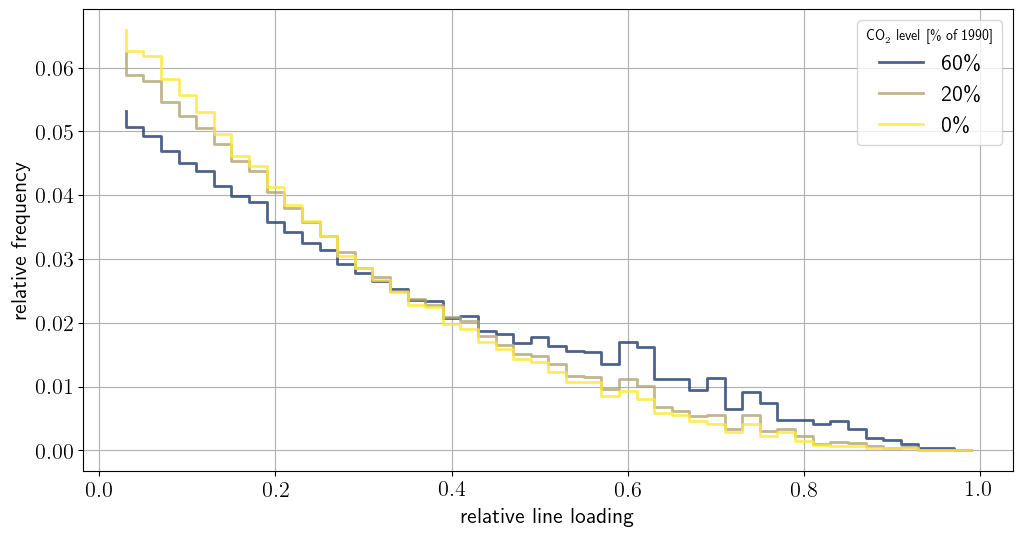

In [26]:
xpoints = (bins + (bins[1]-bins[0])/2)[1:]

# co2lss = np.arange(0.0, 1.0, 0.05)

f, axs_probs = plt.subplots(figsize=(12, 6))

for count, co2l in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.step(xpoints,
            hist_vals[count]/np.sum(hist_vals[count]),
            label=r'{}\%'.format(int(100*co2l)),
            linewidth=2,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
#width = (bins[1]-bins[0])/2,
# label = 'data')
# axs_probs.set_xlim([0, 0.8])
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'relative line loading', fontsize=16)
axs_probs.set_ylabel(r'relative frequency', fontsize=16)
axs_probs.grid(True)
# ax.set_yscale('log')
# ax.set_ylim([4e-3,1e-1])
plt.savefig(save_path+'line_loadings_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()


# Figure 8 - Mitigation Inertia

In [27]:
from utils.plot_mitigation_strategies import plot_map_inertia_placement_final, calc_inertia_placement_ref_loss, color1, color2

# n_nodes = 400
# resolve_strategy = "random"
# delta_rot = 5000
# # for co2_lvl in [0.0 0.1, 0.2, 0.3, 0.4, 0.5]:
# for co2_lvl in [0.1]:
#     print(f"Running for co2_lvl: {co2_lvl}")
#     plot_map_inertia_placement_final(
#         co2_lvl,
#         nn=400,
#         max_iter=10000,
#         max_node_size=800,
#         edge_width=0.2,
#         delta_Erot=delta_rot,
#         resolve_strategy=resolve_strategy,
#         save_fig=True,
#     )

In [28]:
co2_lvl_ref = 0.6
inertia_needed_by_lvl = {}
ref_loss_factors = (1,2)
for ref_loss_factor in ref_loss_factors:
    inertia_at_ref_loss_by_lvl = calc_inertia_placement_ref_loss(co2_lvl_ref=co2_lvl_ref, ref_loss_factor=ref_loss_factor, co2_lvls=co2ls)
    inertia_needed_by_lvl[ref_loss_factor] = inertia_at_ref_loss_by_lvl

<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\%'
<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/3840790387.py:32: SyntaxWarning: invalid escape sequence '\%'
  label = label.replace("co2refString", str(int(100 * co2_lvl_ref)) + "\%")
/tmp/ipykernel_20855/3840790387.py:34: SyntaxWarning: invalid escape sequence '\c'
  label = label.replace("ref_loss_factor", str(ref_loss_factor)+"\cdot")
/tmp/ipykernel_20855/3840790387.py:45: SyntaxWarning: invalid escape sequence '\%'
  ax_inertia_needed.set_xlabel("CO2 level [\% of 1990]")
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  330000.0
loss_ref_multiple: (737,)


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  70000.0


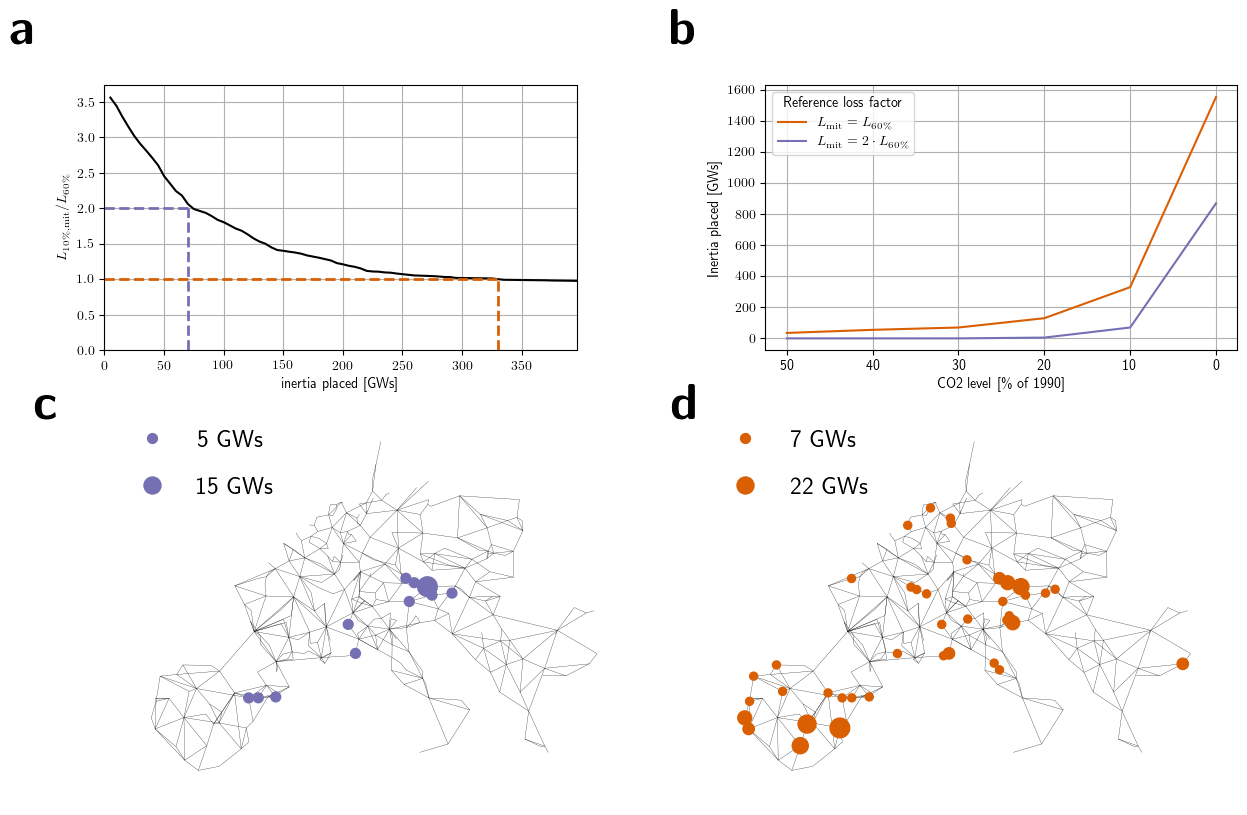

In [29]:
# f.tight_layout()
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

colors = color1, color2
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

co2_lvl_map = 0.1

f = plt.figure(figsize=(12, 7.5))
gs = GridSpec(2, 1, figure=f, height_ratios=[1, 1.5])
gs_lines = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.4)
gs_maps = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.1)
ax_loss_reduction = f.add_subplot(gs_lines[0])
ax_inertia_needed = f.add_subplot(gs_lines[1])
axs_maps = [f.add_subplot(gs_maps[i]) for i in range(2)]

unit = "GWs"
if unit == "GWs":
    unit_factor = 1e-3
elif unit == "MWs":
    unit_factor = 1
else:
    raise ValueError(f"Unit '{unit}' not known!")

# inertia needed by lvl
for i,ref_loss_factor in enumerate(ref_loss_factors):
    inertia_at_ref_loss_by_lvl = inertia_needed_by_lvl[ref_loss_factor] 
    label = "$L_{\\textrm{mit}}=ref_loss_factor L_{\\textrm{co2refString}}$"
    # label = label.replace("co2string", str(int(100 * co2_lvl_map)) + "\%")
    label = label.replace("co2refString", str(int(100 * co2_lvl_ref)) + "\%")
    if ref_loss_factor != 1:
        label = label.replace("ref_loss_factor", str(ref_loss_factor)+"\cdot")
    else:
        label = label.replace("ref_loss_factor", "")
    # label = label.replace("ref_loss_factor", str(ref_loss_factor))
    ax_inertia_needed.plot(np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100, np.array(list(inertia_at_ref_loss_by_lvl.values()))*unit_factor, label=label, color=colors[i])
    
# ax_inertia_needed.plot(np.array(co2ls) * 100, np.array(inertia_at_ref_loss_by_lvl) *unit_factor)
# invert x axis
ax_inertia_needed.legend(title="Reference loss factor")
# plt.legend(title="$\\Delta E_0 [MWhs]$")
ax_inertia_needed.set_ylabel(f"Inertia placed [{unit}]")
ax_inertia_needed.set_xlabel("CO2 level [\% of 1990]")
ticks = np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100
ax_inertia_needed.set_xticks(ticks, labels=[str(int(i)) for i in ticks])
if ticks[0]<ticks[-1]:
    ax_inertia_needed.invert_xaxis()
ax_inertia_needed.grid(True)
for i, ref_loss_factor in enumerate(ref_loss_factors):
    plot_curve = i==0
    plot_map_inertia_placement_final(
        axes=(axs_maps[1-i], ax_loss_reduction),
        co2_lvl = co2_lvl_map,
        nn=400,
        max_iter=10000,
        max_node_size=200,
        edge_width=0.2,
        delta_Erot=5000,
        rocof_thres=-1,
        l_share=0.0,
        resolve_strategy="random",
        show_step_number = False,
        plot_split_number = False,
        save_fig=False,
        co2_lvl_ref = co2_lvl_ref,
        ref_loss_factor=ref_loss_factors[i],
        unit = unit,
        color=colors[i],
        plot_curve=plot_curve
        )
    
ax_loss_reduction.set_xlim(0, inertia_needed_by_lvl[1][co2_lvl_map]*unit_factor*1.2)

f.tight_layout()
for ax, label in zip([ax_loss_reduction, ax_inertia_needed], labels):
    ax.text(0 - 0.2, 1+0.2,
            label,
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=ax.transAxes)
axs_maps[0].text(0 - 0.13, 1,
            labels[2],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[0].transAxes)
axs_maps[1].text(0 - 0.05, 1,
            labels[3],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[1].transAxes)

# for i,ax in enumerate(axs_maps):
#     ax.title("Synthetic inertia placement")

# axs_maps[0].text(0.2, 1+0.06,
#         r'\textbf{a}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes)
# axs_maps[0].text(1 , 1+0.06,
#         r'\textbf{b}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes
#         )
# ax_map.text(1 , 0.5,
#         r'\textbf{c}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=ax_map.transAxes
#         )
    

f.savefig(save_path+f'syn_inertia_mitigation_{co2_lvl_map}.pdf',bbox_inches = 'tight')

# line extension mitigation

## inspecting induced loss by trigger line

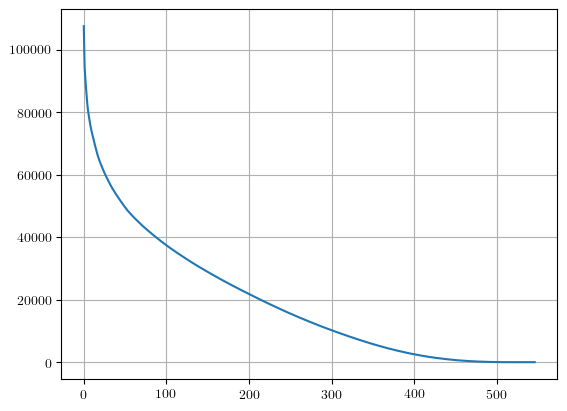

In [30]:
co2l=0.1
split_significance = pd.read_csv(path_to_evaluation_results + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)

trigger0 = split_significance.loc[:,["lost_load_rocof_share","init_failures_0"],].groupby("init_failures_0").sum()
trigger1 = split_significance.loc[:,["lost_load_rocof_share","init_failures_1"],].groupby("init_failures_1").sum()
trigger1.rename_axis("trigger", inplace=True)
trigger0.rename_axis("trigger", inplace=True)
loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
loss_by_trigger.rename_axis("trigger", inplace=True)
loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_rocof_share, fill_value=0)
loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_rocof_share, fill_value=0)

loss_by_trigger_sorted = loss_by_trigger.sort_values()
loss_curve = loss_by_trigger_sorted.cumsum()
plt.plot(np.arange(len(loss_curve)),loss_curve.values[::-1])
plt.grid()

## mitigation

<>:85: SyntaxWarning: invalid escape sequence '\%'
<>:86: SyntaxWarning: invalid escape sequence '\%'
<>:131: SyntaxWarning: invalid escape sequence '\%'
<>:132: SyntaxWarning: invalid escape sequence '\%'
<>:85: SyntaxWarning: invalid escape sequence '\%'
<>:86: SyntaxWarning: invalid escape sequence '\%'
<>:131: SyntaxWarning: invalid escape sequence '\%'
<>:132: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_20855/1904354727.py:85: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
/tmp/ipykernel_20855/1904354727.py:86: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
/tmp/ipykernel_20855/1904354727.py:131: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
/tmp/ipykernel_20855/1904354727.py:132: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2refSt

/tmp/ipykernel_20855/1904354727.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_20855/1904354727.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


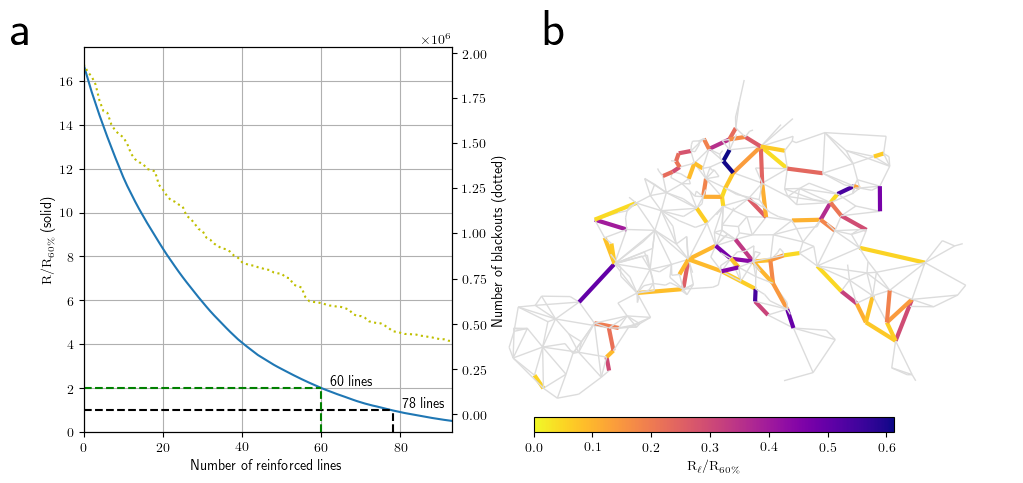

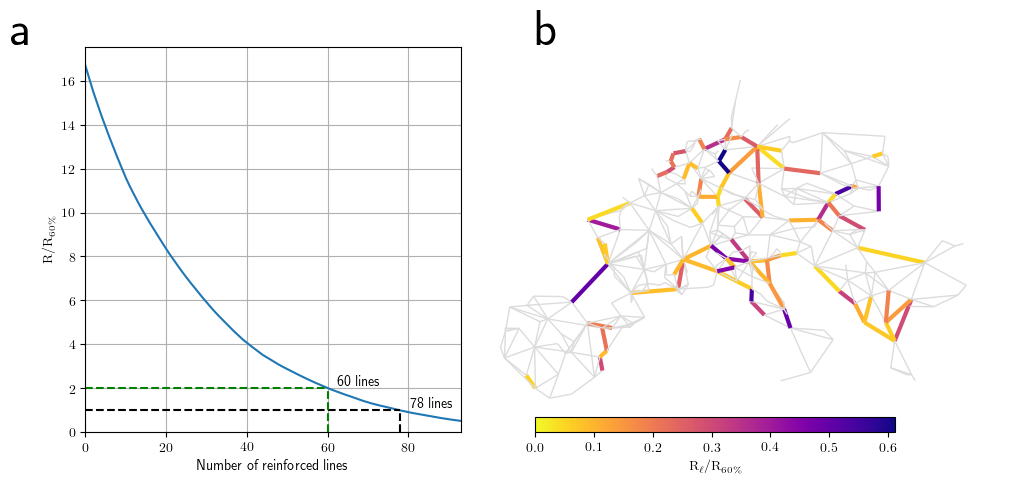

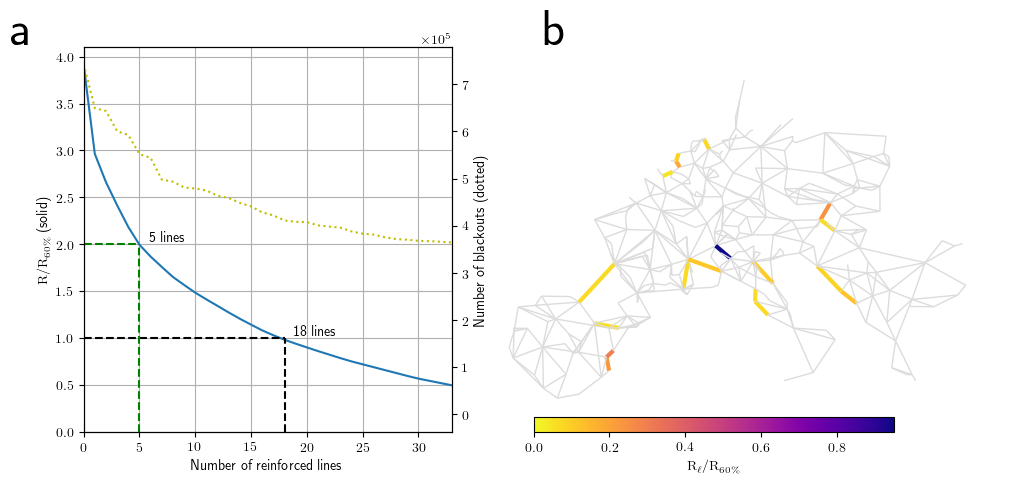

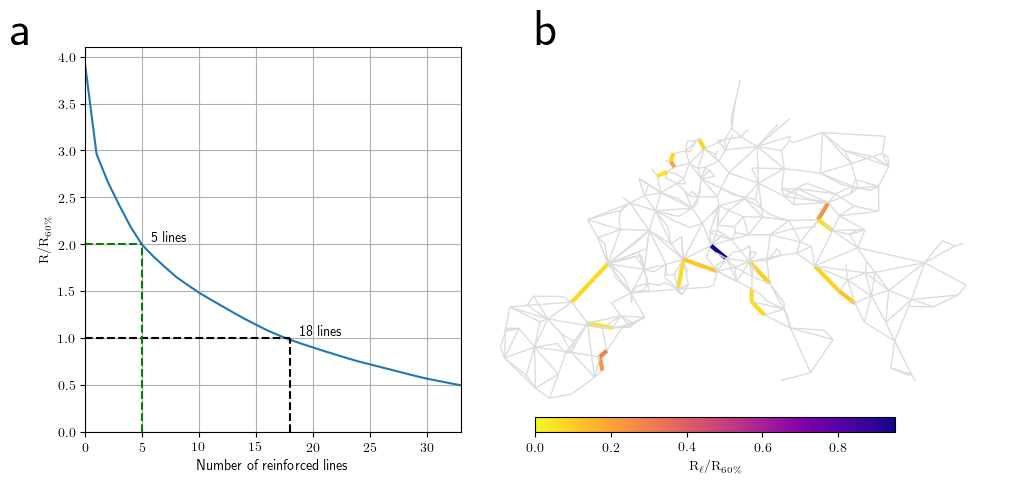

In [31]:
from utils.config import path_to_line_extension_mitigation

co2l_ref=0.6
split_significance_reference = pd.read_csv(path_to_evaluation_results + f"split_properties_Co2L{co2l_ref}_n{n_nodes}.csv", index_col=0)
lost_load_reference_lvl = split_significance_reference.lost_load_rocof_share.sum()

for co2l in [0.0, 0.1]:
    try:
        reinforced_lines, loss_with_mitigation, num_blackouts = pickle.load(open(path_to_line_extension_mitigation + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
    except FileNotFoundError:
        split_significance = pd.read_csv(path_to_evaluation_results + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        remaining_splits = split_significance[split_significance.lost_load_rocof_share>0]
        remaining_splits = remaining_splits.loc[:, ["lost_load_rocof_share","init_failures_0", "init_failures_1"]]

        loss_with_mitigation = [split_significance.lost_load_rocof_share.sum()]
        reinforced_lines = []
        num_blackouts = [remaining_splits.shape[0]]

        while remaining_splits.shape[0]>0:
            trigger0 = remaining_splits.loc[:,["lost_load_rocof_share","init_failures_0"],].groupby("init_failures_0").sum()
            trigger1 = remaining_splits.loc[:,["lost_load_rocof_share","init_failures_1"],].groupby("init_failures_1").sum()
            trigger1.rename_axis("trigger", inplace=True)
            trigger0.rename_axis("trigger", inplace=True)
            loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
            loss_by_trigger.rename_axis("trigger", inplace=True)
            loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_rocof_share, fill_value=0)
            loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_rocof_share, fill_value=0)

            trigger = loss_by_trigger.idxmax()
            remaining_splits = remaining_splits[(remaining_splits.init_failures_1!=trigger) & (remaining_splits.init_failures_0!=trigger)]
            loss_with_mitigation.append(remaining_splits.lost_load_rocof_share.sum())
            reinforced_lines.append(trigger)
            num_blackouts.append(remaining_splits.shape[0])

        with open(path_to_line_extension_mitigation + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
            pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts), f)
            

    # use latex
    mpl.style.use('default')
    plt.rc('text', usetex=True)
    plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

    for plot_blackout_number in [True, False]:

        num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
        num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

        # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
        fig = plt.figure(figsize=(12,5))
        
        # gs = GridSpec(1, 2, figure=f)
        if plot_blackout_number:
            wspace=0.02
        else:
            wspace=-0.02
        gs = GridSpec(1, 2, figure=f, width_ratios=[1.2,1.8], wspace=wspace)
        ax = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1])
        
        ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

        if plot_blackout_number:
            # add second y axis
            ax2 = ax.twinx()
            ax2.plot(np.arange(len(num_blackouts)),num_blackouts, color='y', linestyle='dotted')
            ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
            ax2.set_ylabel('Number of blackouts (dotted)')
        
        right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
        ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
        ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
        ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
        ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
        ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.set_xlim(0,right_xlim)
        ax.set_ylim(bottom=00)
        
        ax.set_xlabel('Number of reinforced lines')
        # y_label = "$L_{\\textrm{co2string,mit}}/L_{\\textrm{co2refString}}$"
        # y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        # y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        if plot_blackout_number:
            y_label += " (solid)"
        ax.set_ylabel(y_label)
        ax.grid()

        fname = "loss_reduction_"
        if plot_blackout_number:
            fname += "blackouts_"
        fname += f"vs_reinforced_lines_CO2{co2l}.pdf"
        
        reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
        mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
        mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
        mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
        mitigated_loss_selected = -np.ones(n_lines)
        mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

        width= 2*(mitigated_loss_selected>0).astype(int) + 1
        # cmap = "cividis_r"
        # cmap = plt.get_cmap('cividis_r')
        cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
        cmap.set_under('gainsboro', 1.0)

        nodes = nx.draw_networkx_nodes(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    node_color='black',
                                    node_size=0)

        edges = nx.draw_networkx_edges(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                    edge_color=mitigated_loss_selected,
                                    width=width,
                                    edge_cmap=cmap,
                                    edge_vmin=0,
                                    # edge_vmax=np.log10(vmax)
                                    )
        ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
        # plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label='Normalized mitigated loss [a.u.]', shrink=0.5, orientation="horizontal")
        y_label = "$\\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
        ax_map.axis("off")
        
        ax.text(0 - 0.2, 1+0.04,
                "a",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax.transAxes)
        
        ax_map.text(0 + 0.15, 1+0.04,
                "b",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax_map.transAxes)

        plt.savefig(save_path+fname, bbox_inches='tight', dpi=200)

## line extension order

/tmp/ipykernel_5607/607704569.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


(-12.667160763087617, 31.78762499557129, 34.58668303037069, 59.25888901201393)

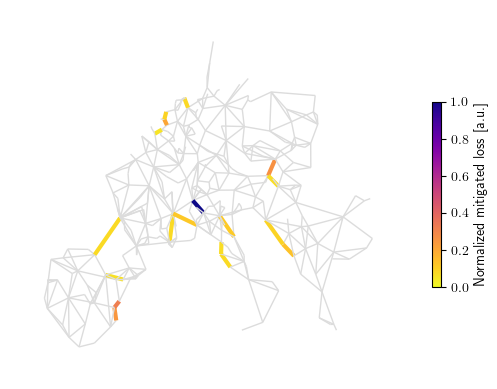

In [129]:
# fig, ax = plt.subplots()

# reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
# lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
# reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
# mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
# mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
# mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
# mitigated_loss_selected = -np.ones(n_lines)
# mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]

# width= 2*(mitigated_loss_selected>0).astype(int) + 1
# # cmap = "cividis_r"
# # cmap = plt.get_cmap('cividis_r')
# cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
# cmap.set_under('gainsboro', 1.0)

# nodes = nx.draw_networkx_nodes(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             node_color='black',
#                             node_size=0)

# edges = nx.draw_networkx_edges(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
#                             width=width,
#                             edge_cmap=cmap,
#                             edge_vmin=0,
#                             # edge_vmax=np.log10(vmax)
#                             )

# plt.colorbar(edges, ax=ax, label='Normalized mitigated loss [a.u.]', shrink=0.5)
# plt.axis("off")